# Modelagem computacional de um acidente envolvendo vazamento de estireno em Manaus

O gás envolvido no vazamento em Manaus foi estireno (mais precisamente, monômero de estireno). O incidente ocorreu por volta das 17:36, na data 15/07/2026, em uma unidade da empresa Innova no Distrito Industrial de Manaus. Imagens térmicas, logo após o acidente, mostraram que o casco do tanque alcançou temperatura média de 72°C.

1.   O que é o estireno?

O estireno (C₈H₈) é uma substância amplamente utilizada na fabricação de Poliestireno (isopor), ABS (plástico de eletrodomésticos e peças automotivas), Borracha sintética, Resinas de fibra de vidro, Embalagens plásticas e etc.

À temperatura ambiente, ele é um líquido incolor que evapora facilmente, formando vapores com odor adocicado característico. Esses vapores são tóxicos quando inalados em concentrações elevadas e também são inflamáveis.

2.   Efeitos da exposição

Os sintomas relatados em Manaus são compatíveis com a exposição aos vapores de estireno como irritação dos olhos, irritação das vias respiratórias, dor de cabeça, tontura, náusea e dificuldade para respirar. Segundo as notícias, pelo menos 149 pessoas procuraram atendimento médico após o incidente.

# **Fenômenos investigados no modelo:**

1.   aquecimento do sistema;
2.   transferência de calor;
3.   possível contribuição da polimerização;
4.   evaporação;
5.   pressão interna;
6.   integridade estrutural;
7.   liberação e dispersão atmosférica



## Contexto do acidente

O presente estudo foi motivado pelo acidente envolvendo o vazamento de
monômero de estireno em Manaus, ocorrido em 15 de julho de 2026. A reportagem e os registros visuais utilizados como referência para a
contextualização do evento podem ser consultados na fonte original.

**Fonte:** G1 / Prefeitura de Manaus.

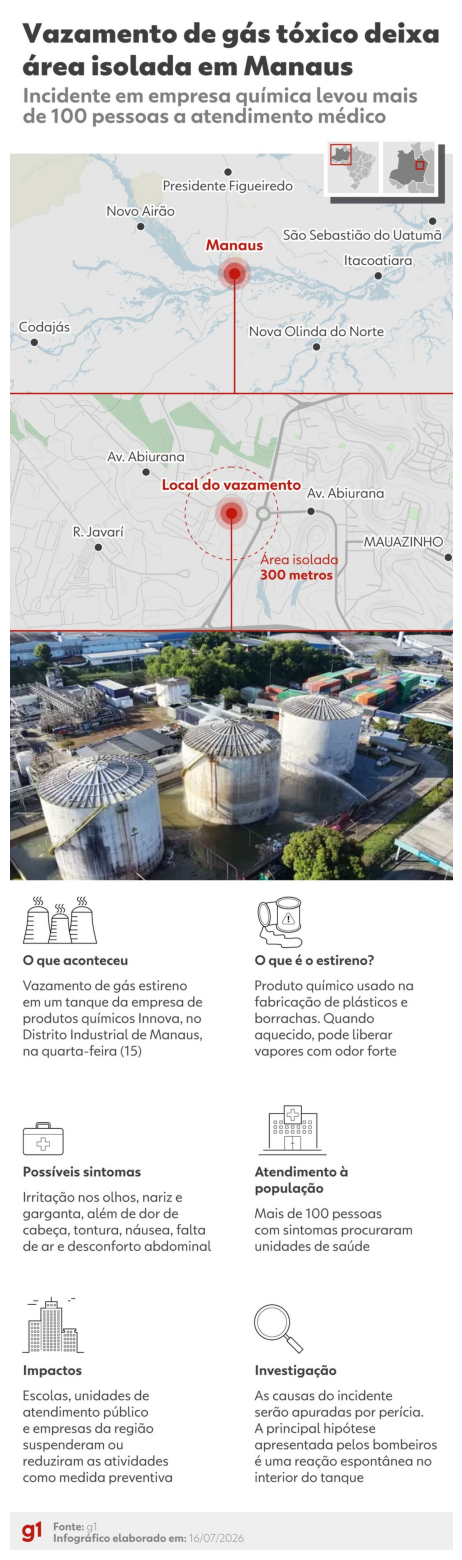

In [ ]:
# ============================================================
# Figura - Infográfico do acidente com estireno em Manaus
# ============================================================
# Este bloco realiza o carregamento e a exibição de um
# infográfico hospedado na internet utilizando a biblioteca
# requests para download da imagem, PIL (Pillow) para leitura
# e Matplotlib para visualização.
#
# A figura apresenta uma representação esquemática do acidente
# ocorrido em 15/07/2026 na unidade da Innova, no Distrito
# Industrial de Manaus, destacando o tanque de armazenamento
# de estireno, a dispersão dos vapores e a atuação das equipes
# de emergência.
#
# Fonte da imagem:
# G1 Amazonas – Infográfico sobre o vazamento de estireno em
# Manaus (2026).
#
# Fonte da notícia:
# https://g1.globo.com/am/amazonas/
# ============================================================

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

url = "https://s2-g1.glbimg.com/2xfaL_vS_YTfaZzfYJ_eGwqFjxI=/0x0:1300x4522/984x0/smart/filters:strip_icc()/i.s3.glbimg.com/v1/AUTH_59edd422c0c84a879bd37670ae4f538a/internal_photos/bs/2026/S/A/xwByApQxejwW8oXEEv2w/infografico-vazamento-gas.png"

img = Image.open(BytesIO(requests.get(url).content))

plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")
plt.show()

## 1 – Bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas ao longo do simulador. O módulo `dataclasses` é empregado para organizar as propriedades do tanque e do estireno em estruturas de dados. A biblioteca `math` fornece funções matemáticas básicas, enquanto o `NumPy` é utilizado para operações numéricas, manipulação de vetores e cálculos necessários à resolução do balanço de energia e dos demais modelos físicos implementados no trabalho.

In [ ]:
# ==========================================================
# 1 - Bibliotecas
# ==========================================================
from dataclasses import dataclass, field
import math
import numpy as np
import textwrap

## 2 – Dados do tanque
  Os dados geométricos e construtivos do tanque foram obtidos a partir de duas fontes complementares. As dimensões do tanque envolvido no acidente foram inicialmente estimadas por medições realizadas com as ferramentas de régua do Google Maps e Google Earth, resultando em um diâmetro aproximado de **28 m** e altura de aproximadamente 18 m. Em seguida, foi realizada uma pesquisa bibliográfica para identificar um tanque com características semelhantes.

O tanque descrito por **Agho et al. (2017)** apresentou excelente concordância com as dimensões observadas nas imagens de satélite, adotando **27,4 m de diâmetro**, **17,5 m de altura**, capacidade nominal de **10.000 m³**, construção conforme a norma **API 650 (12ª edição)**, material **ASTM A36**, teto cônico (*cone roof*), sete cursos (*shell courses*) de 2,5 m de altura e *corrosion allowance* de 3 mm.

Dessa forma, os dados construtivos utilizados neste simulador foram baseados no trabalho de Agho et al. (2017), por apresentarem elevada compatibilidade com as dimensões estimadas do tanque acidentado e fornecerem todas as informações necessárias para a modelagem geométrica e térmica do sistema.

 Geometria baseada no artigo:
 "Design, Construction and Testing of a Petroleum Product
 Storage Tank (10 Million Litre Capacity)"

DOI: http://dx.doi.org/10.24018/ejers.2017.2.3.308

 Observações:
 - Apenas a geometria e as características construtivas foram
   utilizadas neste trabalho.
 - As propriedades do fluido foram substituídas pelas do
   estireno (Styrene), não sendo utilizada a densidade do
   produto considerada no artigo original.
 - Para simplificar a modelagem térmica, o teto cônico foi
   desconsiderado, sendo o tanque representado por um cilindro
   vertical de mesma altura e diâmetro.

In [ ]:
# ==========================================================
# 2 - Dados do tanque
# ==========================================================

@dataclass
class Tanque:
    """
    Tanque cilíndrico vertical baseado em:

    Agho et al. (2017)
    Design Construction and Testing of a Petroleum Product
    Storage Tank 10 Million Litre Capacity

    Projeto conforme API 650 (12th Edition).
    """

    # ======================================================
    # GEOMETRIA
    # ======================================================

    diametro: float                 # m
    altura: float                   # m

    # ======================================================
    # DADOS DO PROJETO
    # ======================================================

    norma: str = "API 650 (12th Edition)"

    referencia: str = (
        "Agho et al. (2017) - Design Construction and "
        "Testing of a Petroleum Product Storage Tank "
        "10 Million Litre Capacity"
    )

    material: str = "ASTM A36"

    capacidade_nominal: float = 10000.0      # m³

    tipo_teto: str = "Cone Roof"

    numero_shell_courses: int = 7

    altura_shell_course: float = 2.5         # m

    corrosion_allowance: float = 0.003       # m

    # Espessuras dos cursos (API 650)

    espessuras: list = field(default_factory=lambda: [
        0.014,   # Curso 1
        0.012,   # Curso 2
        0.010,   # Curso 3
        0.010,   # Curso 4
        0.008,   # Curso 5
        0.006,   # Curso 6
        0.006    # Curso 7
    ])

    # ======================================================
    # CONDIÇÃO OPERACIONAL
    # ======================================================

    nivel_liquido: float = 0.90

    temperatura_liquido: float = 30.0

    temperatura_parede: float = 30.0

    temperatura_ambiente: float = 30.0

    pressao_interna: float = 101325.0

    # ======================================================
    # PROPRIEDADES GEOMÉTRICAS
    # ======================================================

    @property
    def raio(self):
        return self.diametro / 2

    @property
    def area_base(self):
        return math.pi * self.raio**2

    @property
    def area_lateral(self):
        return math.pi * self.diametro * self.altura

    @property
    def area_total(self):
        return self.area_lateral + 2 * self.area_base

    @property
    def volume_total(self):
        return self.area_base * self.altura

    @property
    def altura_liquido(self):
        return self.altura * self.nivel_liquido

    @property
    def volume_liquido(self):
        return self.volume_total * self.nivel_liquido

    @property
    def volume_vapor(self):
        return self.volume_total - self.volume_liquido

    # ======================================================
    # MASSA DO CASCO
    # ======================================================

    def massa_shell(self, densidade_aco=7850):

        area_curso = math.pi * self.diametro * self.altura_shell_course

        massa = 0

        for esp in self.espessuras:

            volume = area_curso * esp

            massa += volume * densidade_aco

        return massa

    # ======================================================
    # RESUMO
    # ======================================================

    def resumo(self):

        print("=" * 60)
        print("DADOS DO TANQUE")
        print("=" * 60)

        print(f"Norma.................... {self.norma}")
        print(f"Material................. {self.material}")
        print(f"Teto..................... {self.tipo_teto}")
        print(f"Capacidade nominal....... {self.capacidade_nominal:.0f} m³")

        print()

        print(f"Diâmetro................. {self.diametro:.2f} m")
        print(f"Altura................... {self.altura:.2f} m")
        print(f"Raio..................... {self.raio:.2f} m")

        print()

        print(f"Nº shell courses......... {self.numero_shell_courses}")
        print(f"Altura por curso......... {self.altura_shell_course:.2f} m")
        print(f"Corrosion allowance...... {self.corrosion_allowance*1000:.0f} mm")

        print()

        print("Espessuras dos cursos (mm)")

        for i, esp in enumerate(self.espessuras):

            print(f"   Curso {i+1}: {esp*1000:.0f}")

        print()

        print(f"Área lateral............. {self.area_lateral:.2f} m²")
        print(f"Área total............... {self.area_total:.2f} m²")

        print()

        print(f"Volume total............. {self.volume_total:.2f} m³")
        print(f"Volume líquido........... {self.volume_liquido:.2f} m³")
        print(f"Volume vapor............. {self.volume_vapor:.2f} m³")

        print()

        print(f"Nível do líquido......... {100*self.nivel_liquido:.1f} %")

        print()

        print(f"Massa do casco........... {self.massa_shell():.0f} kg")

        print("=" * 60)

# Saída

tanque = Tanque(
diametro=27.4,
altura=17.5,
nivel_liquido=0.90
)

tanque.resumo()

DADOS DO TANQUE
Norma.................... API 650 (12th Edition)
Material................. ASTM A36
Teto..................... Cone Roof
Capacidade nominal....... 10000 m³

Diâmetro................. 27.40 m
Altura................... 17.50 m
Raio..................... 13.70 m

Nº shell courses......... 7
Altura por curso......... 2.50 m
Corrosion allowance...... 3 mm

Espessuras dos cursos (mm)
   Curso 1: 14
   Curso 2: 12
   Curso 3: 10
   Curso 4: 10
   Curso 5: 8
   Curso 6: 6
   Curso 7: 6

Área lateral............. 1506.39 m²
Área total............... 2685.68 m²

Volume total............. 10318.80 m³
Volume líquido........... 9286.92 m³
Volume vapor............. 1031.88 m³

Nível do líquido......... 90.0 %

Massa do casco........... 111495 kg


## 3 – Propriedades do estireno

O estireno (C₈H₈) é um hidrocarboneto aromático amplamente utilizado na produção de polímeros, sendo classificado como um líquido inflamável e volátil. Suas propriedades físico-químicas influenciam diretamente os fenômenos de transferência de calor, evaporação, pressurização e dispersão atmosférica, tornando sua correta caracterização fundamental para a simulação do acidente.

As propriedades adotadas neste trabalho foram compiladas a partir de bases de dados e documentos técnicos reconhecidos internacionalmente, incluindo o **NIST Chemistry WebBook**, o **ATSDR – Toxicological Profile for Styrene**, o **National Toxicology Program (NTP)** e o **AmSty – Styrene Monomer Safe Handling Guide**. Foram selecionados parâmetros relevantes para a modelagem térmica e físico-química do sistema, como densidade, calor específico, condutividade térmica, viscosidade, calor de vaporização, pressão de vapor e limites de inflamabilidade.


In [ ]:
# ==========================================================
# 3 - Propriedades do Estireno
# ==========================================================

@dataclass
class Estireno:
    """
    Propriedades físico-químicas do estireno (Styrene Monomer).

    Dados compilados a partir de:

    - NIST Chemistry WebBook
    - ATSDR - Toxicological Profile for Styrene
    - National Toxicology Program (NTP)
    - AmSty - Styrene Monomer Safe Handling Guide
    """

    # ======================================================
    # IDENTIFICAÇÃO
    # ======================================================

    nome: str = "Estireno"

    formula: str = "C8H8"

    CAS: str = "100-42-5"

    massa_molar: float = 104.15          # g/mol

    # ======================================================
    # PROPRIEDADES FÍSICAS
    # ======================================================

    densidade: float = 906.0             # kg/m³ (25 °C)

    densidade_vapor: float = 3.6         # ar = 1

    temperatura_fusao: float = -30.6     # °C

    temperatura_ebulicao: float = 145.2  # °C

    temperatura_critica: float = 363.8   # °C

    pressao_critica: float = 3.83e6      # Pa

    # ======================================================
    # PROPRIEDADES TÉRMICAS
    # ======================================================

    calor_especifico: float = 1730.0     # J/(kg.K)

    condutividade: float = 0.13          # W/(m.K)

    viscosidade: float = 0.00072         # Pa.s

    calor_vaporizacao: float = 35200.0   # J/mol

    # ======================================================
    # PROPRIEDADES DE VAPOR
    # ======================================================

    pressao_vapor: float = 640.0         # Pa (25 °C)

    # ======================================================
    # SEGURANÇA
    # ======================================================

    flash_point: float = 31.0            # °C

    autoignicao: float = 490.0           # °C

    limite_inferior: float = 1.1         # %

    limite_superior: float = 6.1         # %

    # ======================================================
    # REFERÊNCIAS
    # ======================================================

    referencias: tuple = (

        "NIST Chemistry WebBook",

        "ATSDR - Toxicological Profile for Styrene",

        "National Toxicology Program (NTP)",

        "AmSty - Styrene Monomer Safe Handling Guide"

    )

    # ======================================================
    # RESUMO
    # ======================================================

    def resumo(self):

        print("=" * 60)
        print("PROPRIEDADES DO ESTIRENO")
        print("=" * 60)

        print(f"Nome...................... {self.nome}")
        print(f"Fórmula................... {self.formula}")
        print(f"CAS....................... {self.CAS}")
        print(f"Massa molar............... {self.massa_molar:.2f} g/mol")

        print()

        print("PROPRIEDADES FÍSICAS")

        print(f"Densidade.................... {self.densidade:.1f} kg/m³")
        print(f"Densidade relativa do vapor.. {self.densidade_vapor:.1f}")
        print(f"Ponto de fusão............... {self.temperatura_fusao:.1f} °C")
        print(f"Ponto de ebulição............ {self.temperatura_ebulicao:.1f} °C")
        print(f"Temperatura crítica.......... {self.temperatura_critica:.1f} °C")
        print(f"Pressão crítica.............. {self.pressao_critica/1e6:.2f} MPa")

        print()

        print("PROPRIEDADES TÉRMICAS")

        print(f"Calor específico......... {self.calor_especifico:.0f} J/(kg.K)")
        print(f"Condutividade............ {self.condutividade:.2f} W/(m.K)")
        print(f"Viscosidade.............. {self.viscosidade*1000:.2f} mPa.s")
        print(f"Calor de vaporização..... {self.calor_vaporizacao/1000:.1f} kJ/mol")

        print()

        print("PROPRIEDADES DO VAPOR")

        print(f"Pressão de vapor......... {self.pressao_vapor/1000:.3f} kPa")

        print()

        print("SEGURANÇA")

        print(f"Flash Point.............. {self.flash_point:.1f} °C")
        print(f"Autoignição.............. {self.autoignicao:.0f} °C")
        print(f"LFL...................... {self.limite_inferior:.1f} %")
        print(f"UFL...................... {self.limite_superior:.1f} %")

        print()

        print("REFERÊNCIAS")

        for ref in self.referencias:
            print(f"• {ref}")

        print("=" * 60)


# ==========================================================
# 3.1 - Classe Estireno
# ==========================================================

estireno = Estireno()

estireno.resumo()

Cp_estireno = estireno.calor_especifico  # J/(kg.K)

PROPRIEDADES DO ESTIRENO
Nome...................... Estireno
Fórmula................... C8H8
CAS....................... 100-42-5
Massa molar............... 104.15 g/mol

PROPRIEDADES FÍSICAS
Densidade.................... 906.0 kg/m³
Densidade relativa do vapor.. 3.6
Ponto de fusão............... -30.6 °C
Ponto de ebulição............ 145.2 °C
Temperatura crítica.......... 363.8 °C
Pressão crítica.............. 3.83 MPa

PROPRIEDADES TÉRMICAS
Calor específico......... 1730 J/(kg.K)
Condutividade............ 0.13 W/(m.K)
Viscosidade.............. 0.72 mPa.s
Calor de vaporização..... 35.2 kJ/mol

PROPRIEDADES DO VAPOR
Pressão de vapor......... 0.640 kPa

SEGURANÇA
Flash Point.............. 31.0 °C
Autoignição.............. 490 °C
LFL...................... 1.1 %
UFL...................... 6.1 %

REFERÊNCIAS
• NIST Chemistry WebBook
• ATSDR - Toxicological Profile for Styrene
• National Toxicology Program (NTP)
• AmSty - Styrene Monomer Safe Handling Guide


4 - Condições Ambientais

As condições ambientais utilizadas na simulação foram obtidas na plataforma NASA POWER para a localização da planta da Videolar, em Manaus (latitude −3,1223° e longitude −59,9563°). Foram utilizados dados horários de irradiância solar incidente (ALLSKY_SFC_SW_DWN), temperatura do ar a 2 m (T2M) e velocidade do vento a 10 m (WS10M) referentes ao dia 15 de julho de 2025, escolhido por apresentar informações meteorológicas completas para o mesmo período do ano em que ocorreu o acidente.

Os dados horários do NASA POWER são tratados como irradiância média durante cada intervalo de uma hora. Numericamente, o valor utilizado no cálculo da potência é expresso em W/m², enquanto a integração temporal com Δt=3600 s fornece a energia correspondente.

=== Condições Ambientais ===
Total de horas: 24
Irradiância máxima : 790.85 Wh/m²
Temperatura máxima : 31.13 °C
Temperatura mínima : 24.81 °C
Vento máximo       : 1.83 m/s


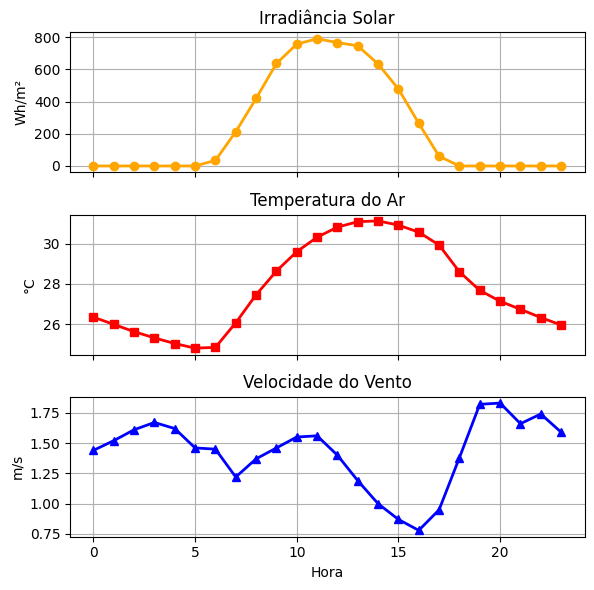

In [ ]:
# ============================================================
# 04 - CONDIÇÕES AMBIENTAIS
# Dados meteorológicos obtidos da plataforma NASA POWER
# Local: Manaus - AM
# Fonte:
# NASA POWER - Prediction Of Worldwide Energy Resources
# https://power.larc.nasa.gov/
#
# Local:
# Latitude  = -3.1223°
# Longitude = -59.9563°
#
# Variáveis:
# ALLSKY_SFC_SW_DWN (CERES SYN1deg)
# T2M (MERRA-2)
# WS10M (MERRA-2)
#
# Data utilizada:
# 15/07/2025 (LST)
# ============================================================

# Hora do dia
hora = np.arange(24)

# Irradiância solar incidente (Wh/m²)
irradiancia = np.array([
     0.00,   0.00,   0.00,   0.00,
     0.00,   0.00,  34.55, 212.52,
   419.42, 636.80, 757.15, 790.85,
   766.65, 747.05, 633.15, 478.40,
   264.83,  60.40,   0.00,   0.00,
     0.00,   0.00,   0.00,   0.00
])

# Temperatura do ar (°C)
temperatura_ar = np.array([
    26.35, 25.99, 25.63, 25.32,
    25.04, 24.81, 24.85, 26.07,
    27.46, 28.64, 29.60, 30.32,
    30.82, 31.09, 31.13, 30.92,
    30.57, 29.93, 28.60, 27.68,
    27.14, 26.74, 26.33, 25.96
])

# Velocidade do vento (m/s)
vento = np.array([
    1.44, 1.52, 1.61, 1.67,
    1.62, 1.46, 1.45, 1.22,
    1.37, 1.46, 1.55, 1.56,
    1.40, 1.19, 1.00, 0.87,
    0.78, 0.95, 1.38, 1.82,
    1.83, 1.66, 1.74, 1.59
])

# Verificação

print("=== Condições Ambientais ===")
print(f"Total de horas: {len(hora)}")
print(f"Irradiância máxima : {irradiancia.max():.2f} Wh/m²")
print(f"Temperatura máxima : {temperatura_ar.max():.2f} °C")
print(f"Temperatura mínima : {temperatura_ar.min():.2f} °C")
print(f"Vento máximo       : {vento.max():.2f} m/s")

# ============================================================
# Visualização das condições ambientais
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# ------------------------------------------------------------
# Irradiância solar
# ------------------------------------------------------------
ax[0].plot(hora, irradiancia, 'o-', color='orange', linewidth=2)
ax[0].set_ylabel("Wh/m²")
ax[0].set_title("Irradiância Solar")
ax[0].grid(True)

# ------------------------------------------------------------
# Temperatura do ar
# ------------------------------------------------------------
ax[1].plot(hora, temperatura_ar, 's-', color='red', linewidth=2)
ax[1].set_ylabel("°C")
ax[1].set_title("Temperatura do Ar")
ax[1].grid(True)

# ------------------------------------------------------------
# Velocidade do vento
# ------------------------------------------------------------
ax[2].plot(hora, vento, '^-', color='blue', linewidth=2)
ax[2].set_ylabel("m/s")
ax[2].set_xlabel("Hora")
ax[2].set_title("Velocidade do Vento")
ax[2].grid(True)

plt.tight_layout()
plt.show()

# **5 - TRANSFERÊNCIA DE CALOR**

A evolução da temperatura do estireno é determinada por meio de um balanço global de energia, adotando-se o modelo de parâmetros concentrados (Lumped Capacitance Model), no qual a temperatura do líquido é assumida uniforme em todo o volume do tanque. Nesta primeira etapa, são considerados apenas o aquecimento pela radiação solar incidente e a troca de calor por convecção com o ar atmosférico.

Para o cálculo da convecção, utiliza-se a área lateral do tanque acrescida da área do teto, enquanto a radiação solar é aplicada sobre a área projetada do tanque. O fundo foi desconsiderado por estar em contato com a fundação, onde a transferência de calor ocorre predominantemente por condução com o solo.

Embora exista condução através da parede metálica, esse mecanismo foi desprezado nesta etapa devido à pequena espessura das chapas (6 a 14 mm) e à elevada condutividade térmica do aço ASTM A36, tornando sua resistência térmica muito inferior às resistências convectivas. Assim, admite-se que o calor absorvido pela parede seja rapidamente transferido ao estireno, sem comprometer a representação do comportamento térmico global do sistema.

Em etapas futuras, o modelo poderá ser ampliado para incluir radiação térmica, condução pela parede do tanque e o calor liberado pela polimerização do estireno.

Módulos seguintes:


* 5.1 Áreas de troca térmica

* 5.2 Massa de estireno

* 5.3 Radiação solar

* 5.4 Convecção

* 5.5 Exemplo didático da condução pela parede

* 5.6 Balanço de energia

* 5.7 Visualização

* 5.8 Discussão dos Resultados

TRANSFERÊNCIA DE CALOR
Modelo.................. Lumped Capacitance Model
Hipótese................ Temperatura uniforme no estireno

Mecanismos considerados
• Radiação solar......... Sim
• Convecção.............. Sim
• Condução............... Não (exemplo didático)
• Radiação térmica....... Não
• Polimerização.......... Não

Constantes
Absortividade (α)........ 0.60
Coef. convectivo......... Variável (McAdams)
h mínimo................ 8.66 W/(m².K)
h máximo................ 12.65 W/(m².K)
Temperatura inicial...... 26.35 °C
Passo de tempo........... 3600 s (1 hora)


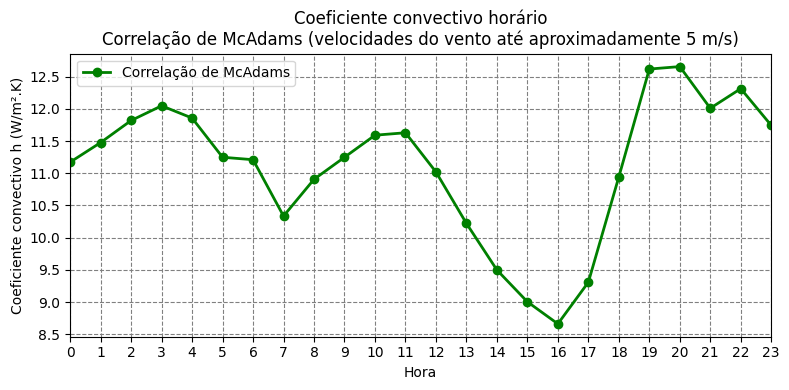

In [ ]:
# ==========================================
# 5 - TRANSFERÊNCIA DE CALOR
# ==========================================
# O aquecimento do estireno será modelado por um balanço global
# de energia (Lumped Capacitance Model), assumindo temperatura
# uniforme em todo o volume do líquido.
#
# Inicialmente serão considerados:
# - aquecimento pela radiação solar;
# - troca de calor por convecção com o ar ambiente.
#
# Em versões futuras poderão ser adicionados:
# - radiação térmica;
# - condução pela parede do tanque;
# - calor de polimerização do estireno.

# ============================================================
# Constantes da transferência de calor
# ============================================================

# Absortividade do aço pintado
alpha = 0.60

# ------------------------------------------------------------
# Temperatura inicial
# Igual à temperatura do ar no primeiro instante da simulação
# (NASA POWER)
# ------------------------------------------------------------
T_estireno = temperatura_ar[0]

# ------------------------------------------------------------
# Coeficiente convectivo
# Correlação de McAdams:
#
# h = 5.7 + 3.8 V
#
# V : velocidade do vento (m/s)
# h : W/(m².K)
# ------------------------------------------------------------
h = 5.7 + 3.8 * vento

# Passo de tempo
dt = 3600              # s (1 hora)

# Saída

print("="*60)
print("TRANSFERÊNCIA DE CALOR")
print("="*60)

print("Modelo.................. Lumped Capacitance Model")
print("Hipótese................ Temperatura uniforme no estireno")

print()

print("Mecanismos considerados")
print(f"• Radiação solar......... Sim")
print(f"• Convecção.............. Sim")
print(f"• Condução............... Não (exemplo didático)")
print(f"• Radiação térmica....... Não")
print(f"• Polimerização.......... Não")

print()

print("Constantes")
print(f"Absortividade (α)........ {alpha:.2f}")
print(f"Coef. convectivo......... Variável (McAdams)")
print(f"h mínimo................ {h.min():.2f} W/(m².K)")
print(f"h máximo................ {h.max():.2f} W/(m².K)")
print(f"Temperatura inicial...... {T_estireno:.2f} °C")
print(f"Passo de tempo........... {dt:.0f} s ({dt/3600:.0f} hora)")

print("="*60)


# Gráfico do Coeficiente Convectivo

# ============================================================
# Coeficiente convectivo
# Correlação de McAdams
# h = 5.7 + 3.8 V
#
# h : W/(m².K)
# V : velocidade do vento (m/s)
#
# Aplicável para convecção forçada em superfícies externas
# submetidas a baixas velocidades do vento (≈ até 5 m/s).
# ============================================================

# Cálculo do coeficiente convectivo horário
h = 5.7 + 3.8 * vento

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    hora,
    h,
    'o-',
    linewidth=2,
    color='green',
    label='Correlação de McAdams'
)

plt.xticks(np.arange(0,24,1))

plt.xlabel("Hora")
plt.ylabel("Coeficiente convectivo h (W/m².K)")

plt.title(
    "Coeficiente convectivo horário\n"
    "Correlação de McAdams (velocidades do vento até aproximadamente 5 m/s)"
)

# Grid principal
plt.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.8,
    color='gray'
)

plt.xlim(0,23)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 5.1 - Área de troca térmica
# ============================================================
# Áreas do tanque que participarão da transferência de calor

# Área lateral do tanque
A_lateral = tanque.area_lateral

# Área superior (teto)
A_topo = np.pi * tanque.raio**2

# Área total exposta
A_convectiva  = A_lateral + A_topo

# Área projetada para incidência solar
A_projetada = tanque.diametro * tanque.altura

print(f"Área lateral    : {A_lateral:.2f} m²")
print(f"Área superior   : {A_topo:.2f} m²")
print(f"Área convectiva : {A_convectiva:.2f} m²")
print(f"Área projetada  : {A_projetada:.2f} m²")

Área lateral    : 1506.39 m²
Área superior   : 589.65 m²
Área convectiva : 2096.04 m²
Área projetada  : 479.50 m²


In [ ]:
# ============================================================
# 5.2 - Massa de estireno
# ============================================================
# Como o balanço de energia será aplicado ao líquido, precisamos da massa.
# Massa total de estireno armazenado no tanque

massa_estireno = tanque.volume_liquido * estireno.densidade

print("=== Massa de Estireno ===")
print(f"Volume de estireno : {tanque.volume_liquido:.2f} m³")
print(f"Densidade          : {estireno.densidade:.2f} kg/m³")
print(f"Massa              : {massa_estireno:.0f} kg")
print(f"Massa              : {massa_estireno/1000:.0f} ton")

=== Massa de Estireno ===
Volume de estireno : 9286.92 m³
Densidade          : 906.00 kg/m³
Massa              : 8413947 kg
Massa              : 8414 ton


## 5.3 – Radiação solar

Após determinar a massa de estireno armazenada no tanque, surge uma nova questão:

> **Como estimar a energia fornecida pela radiação solar ao reservatório ao longo do dia?**

Antes de responder a essa pergunta, é importante esclarecer outra dúvida:

> **O modelo deve calcular potência ou energia?**

Embora essas grandezas estejam relacionadas, elas possuem significados físicos distintos. A **potência térmica** representa a taxa com que a energia é transferida ao reservatório, sendo medida em watts (W). Já a **energia** corresponde ao total acumulado ao longo do tempo, sendo expressa em joules (J) ou, neste trabalho, em megawatt-hora (MWh).

Como o balanço global de energia descreve a evolução temporal da temperatura, a grandeza utilizada inicialmente é a potência térmica absorvida pela radiação solar, dada por

$$
\dot{Q}_{\mathrm{solar}}=\alpha G A_P,
$$

em que:

- $\alpha$ é a absortividade da superfície externa do tanque;
- $G$ é a irradiância solar global incidente obtida da plataforma NASA POWER;
- $A_P$ é a área projetada do reservatório.

Neste trabalho foi adotada uma absortividade igual a **0,60**, valor típico para superfícies metálicas pintadas.

A potência absorvida varia ao longo do dia porque a irradiância solar também varia. Entretanto, muitas vezes é mais intuitivo avaliar **quanta energia o tanque recebeu durante todo o período da simulação**. Essa energia é obtida pela integração da potência no tempo,

$$
Q_{\mathrm{solar}}
=
\dot{Q}_{\mathrm{solar}}\Delta t,
$$

em que $\Delta t=3600$ s corresponde ao intervalo de uma hora entre dois registros consecutivos dos dados meteorológicos.

No código a seguir, calcula-se inicialmente a **potência térmica horária absorvida** pelo reservatório e, posteriormente, integra-se essa potência para obter a **energia solar total** recebida durante o dia. Ao final, é apresentado um gráfico da potência absorvida, permitindo visualizar como ela acompanha diretamente a variação da irradiância solar.

### O que será observado?

Ao executar esta etapa da simulação, o estudante poderá acompanhar a seguinte sequência:

1. Obter a irradiância solar horária proveniente da plataforma NASA POWER;
2. Calcular a potência térmica absorvida pela superfície do tanque utilizando a equação
   $\dot{Q}_{\mathrm{solar}}=\alpha G A_P$;
3. Integrar numericamente essa potência ao longo do tempo;
4. Determinar a energia solar total absorvida durante o dia.

Essa sequência evidencia a diferença entre **potência** e **energia**, mostrando como uma equação física é implementada computacionalmente e como os dados meteorológicos são transformados em uma variável utilizada diretamente no balanço global de energia.

RADIAÇÃO SOLAR
Área projetada............. 479.50 m²
Absortividade.............. 0.60
Irradiância máxima......... 790.85 W/m²
Potência máxima absorvida.. 0.228 MW
Energia absorvida no dia... 1.67 MWh



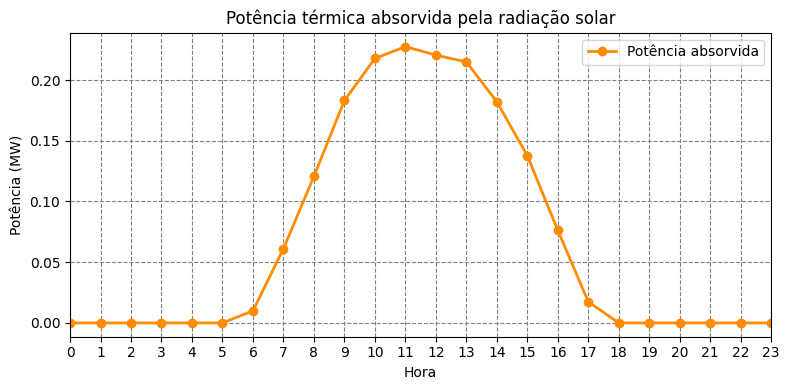

In [ ]:
# ============================================================
# 5.3 - Radiação solar
# ============================================================
# Potência térmica absorvida pelo tanque
#
# Qdot_solar : potência (W)
# E_solar    : energia (MWh)
# ============================================================

# Potência térmica absorvida
Qdot_solar = alpha * irradiancia * A_projetada

print("="*55)
print("RADIAÇÃO SOLAR")
print("="*55)

print(f"Área projetada............. {A_projetada:.2f} m²")
print(f"Absortividade.............. {alpha:.2f}")

print(f"Irradiância máxima......... {irradiancia.max():.2f} W/m²")

print(f"Potência máxima absorvida.. {Qdot_solar.max()/1e6:.3f} MW")

print("="*55)

# ============================================================
# Energia absorvida durante o dia
# ============================================================

E_solar = np.sum(Qdot_solar) * dt / 3.6e9      # MWh

print(f"Energia absorvida no dia... {E_solar:.2f} MWh")

print("")

# ============================================================
# Potência térmica absorvida pela radiação solar
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    hora,
    Qdot_solar/1e6,
    'o-',
    linewidth=2,
    color='darkorange',
    label='Potência absorvida'
)

plt.xticks(np.arange(0,24,1))

plt.xlim(0,23)

plt.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.8,
    color='gray'
)

plt.xlabel("Hora")
plt.ylabel("Potência (MW)")

plt.title(
    "Potência térmica absorvida pela radiação solar"
)

plt.legend()

plt.tight_layout()

plt.show()

## 5.4 – Convecção

Nesta primeira versão do modelo, considera-se a transferência de calor por radiação solar incidente, convecção com o ar atmosférico e condução através da parede metálica do tanque. Para a convecção, utiliza-se a área lateral acrescida da área do teto, enquanto a radiação solar incide sobre a área projetada do tanque. O fundo não é considerado, pois está apoiado sobre a fundação, onde a transferência de calor ocorre predominantemente por condução com o solo.

Os dados meteorológicos indicam velocidades do vento entre aproximadamente **0,8 e 1,8 m/s**, características de vento fraco. Assim, nesta etapa é adotado o coeficiente convectivo de McAdams.

Embora a resistência térmica da parede de aço ASTM A36 seja pequena devido à elevada condutividade térmica do material e à reduzida espessura das chapas (6 a 14 mm), **a condução será considerada neste trabalho por seu caráter didático**. Dessa forma, o modelo representa explicitamente os três mecanismos fundamentais de transferência de calor — radiação, condução e convecção — permitindo compreender a contribuição de cada um para o aquecimento do estireno.

Como condição inicial, considera-se que todo o estireno encontra-se em equilíbrio térmico com o ambiente, assumindo-se inicialmente uma temperatura igual à temperatura do ar. Essa hipótese simplifica a modelagem inicial e é adequada para o início da simulação.

Em etapas futuras, o modelo poderá ser expandido para incluir a radiação térmica entre o tanque e o ambiente e o calor liberado pela reação de polimerização do estireno.

O fluxo de calor por convecção é calculado pela Lei de Resfriamento de Newton:

$$
Q_{conv}=hA\left(T_{ar}-T_{est}\right)
$$

onde:

- $h$ é o coeficiente convectivo (W/m²·K);
- $A$ é a área de troca por convecção (área lateral + teto) (m²);
- $T_{ar}$ é a temperatura do ar (°C);
- $T_{est}$ é a temperatura instantânea do estireno (°C).

O fluxo de calor por convecção será calculado para cada hora da simulação e posteriormente combinado com o fluxo de calor proveniente da radiação solar, permitindo determinar o balanço global de energia e a evolução temporal da temperatura do estireno.

In [ ]:
# ============================================================
# 5.4 - Convecção
# ============================================================
# Troca de calor entre o tanque e o ar ambiente
# Lei de Resfriamento de Newton
#
# Q_conv = h A (T_ar - T_est)
#
# h obtido pela correlação de McAdams
# ============================================================

# Coeficiente convectivo (McAdams)
# h = 5.7 + 3.8 V

h = 5.7 + 3.8 * vento

# Área sujeita à convecção
A_conv = A_lateral + A_topo

print("="*50)
print("=== Convecção ===")
print(f"Área de convecção..... {A_conv:.2f} m²")
print("Coeficiente........... Variável (McAdams)")
print(f"h mínimo.............. {h.min():.2f} W/(m².K)")
print(f"h médio............... {h.mean():.2f} W/(m².K)")
print(f"h máximo.............. {h.max():.2f} W/(m².K)")
print("="*50)

=== Convecção ===
Área de convecção..... 2096.04 m²
Coeficiente........... Variável (McAdams)
h mínimo.............. 8.66 W/(m².K)
h médio............... 11.11 W/(m².K)
h máximo.............. 12.65 W/(m².K)


## 5.5 – Exemplo didático da condução pela parede

Após determinar os mecanismos responsáveis pelo aquecimento do reservatório, surge uma nova questão:

> **A parede metálica do tanque dificulta a transferência de calor para o estireno?**

A condução representa a transferência de calor através da parede metálica do tanque, transportando a energia térmica da superfície externa, aquecida pela radiação solar e pela convecção com o ar ambiente, até a superfície interna em contato com o estireno.

Esse mecanismo é descrito pela Lei de Fourier,

$$
\dot Q_{cond}
=
kA
\frac{\Delta T}{L},
$$

em que:

- $k$ é a condutividade térmica do aço ASTM A36;
- $A$ é a área de condução;
- $L$ é a espessura da parede;
- $\Delta T$ é a diferença de temperatura entre as faces da chapa.

Como o aço apresenta elevada condutividade térmica e as chapas do reservatório possuem espessuras entre 6 e 14 mm, espera-se que a resistência térmica da parede seja muito pequena.

Neste exemplo, utiliza-se o fluxo de calor calculado nas etapas anteriores para estimar qual diferença de temperatura seria necessária para conduzir esse calor através da parede metálica. O objetivo não é incorporar a condução ao balanço principal de energia, mas verificar se a resistência térmica da parede pode ser desprezada na modelagem.

### O que será observado?

Ao executar esta etapa da simulação, o estudante poderá:

1. calcular a potência térmica que atravessa a parede do tanque;
2. aplicar a Lei de Fourier;
3. estimar a diferença de temperatura entre as faces da chapa;
4. verificar se essa diferença é suficientemente pequena para justificar a simplificação adotada no modelo.

Caso a diferença de temperatura obtida seja da ordem de centésimos de grau Celsius, conclui-se que a parede praticamente não limita a transferência de calor entre o ambiente externo e o estireno.

EXEMPLO DIDÁTICO - CONDUÇÃO ATRAVÉS DA PAREDE
Condutividade térmica....... 50.0 W/(m.K)
Espessura média............. 9.4 mm
Área de condução............ 1506.39 m²

Maior potência conduzida.... 239.51 kW
Menor potência conduzida.... -123.26 kW

Maior ΔT na parede.......... 0.02998 °C
Menor ΔT na parede.......... -0.01543 °C


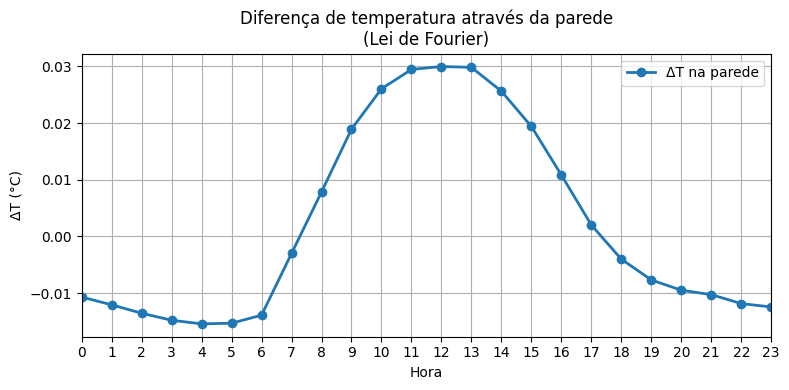

DISCUSSÃO DOS RESULTADOS

Mesmo conduzindo potências térmicas de até 239.5 kW, a
diferença máxima de temperatura entre as faces da parede é
de apenas 0.02998 °C.

Pergunta investigativa:

A parede metálica dificulta a transferência de calor para o
estireno?

Resposta:

Não. A diferença de temperatura necessária para conduzir o
calor através da parede é extremamente pequena, indicando
que sua resistência térmica é praticamente desprezível.

Por esse motivo, nesta primeira versão do simulador, admite-
se que o calor absorvido pela superfície externa seja
rapidamente transferido ao estireno. Assim, a condução
através da parede não é representada explicitamente no
balanço global de energia.

Na próxima etapa, o calor transferido ao estireno será
utilizado no balanço global de energia para determinar a
evolução temporal da temperatura do líquido no interior do
reservatório.



In [ ]:
# ============================================================
# 5.5 - Exemplo didático da condução através da parede
# ============================================================
# Objetivo:
# Mostrar que a parede metálica praticamente não oferece
# resistência à transferência de calor.
#
# A condução NÃO participa do balanço principal de energia.
# Este cálculo é apenas ilustrativo.
# ============================================================

# ------------------------------------------------------------
# Propriedades da parede
# ------------------------------------------------------------

# Condutividade térmica do aço ASTM A36
k = 50.0                  # W/(m.K)

# Espessura média da parede
L = np.mean(tanque.espessuras)

# Área de condução (costado)
A_cond = tanque.area_lateral

# ------------------------------------------------------------
# Potência total que chega à parede
# ------------------------------------------------------------
# Soma das contribuições da radiação solar e da convecção

T_parede = 30.0           # °C (temperatura representativa)

Qdot_conv = h * A_conv * (temperatura_ar - T_parede)

Qdot_cond = Qdot_solar + Qdot_conv

# ------------------------------------------------------------
# Lei de Fourier
#
# Qdot = k A ΔT / L
#
# ΔT = Qdot L / (k A)
# ------------------------------------------------------------

deltaT_parede = (
    Qdot_cond * L /
    (k * A_cond)
)

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("EXEMPLO DIDÁTICO - CONDUÇÃO ATRAVÉS DA PAREDE")
print("="*60)

print(f"Condutividade térmica....... {k:.1f} W/(m.K)")
print(f"Espessura média............. {L*1000:.1f} mm")
print(f"Área de condução............ {A_cond:.2f} m²")

print()

print(f"Maior potência conduzida.... {Qdot_cond.max()/1000:.2f} kW")
print(f"Menor potência conduzida.... {Qdot_cond.min()/1000:.2f} kW")

print()

print(f"Maior ΔT na parede.......... {deltaT_parede.max():.5f} °C")
print(f"Menor ΔT na parede.......... {deltaT_parede.min():.5f} °C")

print("="*60)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    hora,
    deltaT_parede,
    'o-',
    linewidth=2,
    label='ΔT na parede'
)

plt.grid(True)

plt.xticks(np.arange(0,24,1))
plt.xlim(0,23)

plt.xlabel("Hora")
plt.ylabel("ΔT (°C)")

plt.title("Diferença de temperatura através da parede\n(Lei de Fourier)")

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# Conclusão
# ============================================================

def imprimir(texto):
    print(textwrap.fill(texto, width=60))
    print()

print("="*60)
print("DISCUSSÃO DOS RESULTADOS")
print("="*60)
print()

imprimir(
    f"Mesmo conduzindo potências térmicas de até "
    f"{Qdot_cond.max()/1000:.1f} kW, a diferença máxima "
    f"de temperatura entre as faces da parede é de apenas "
    f"{deltaT_parede.max():.5f} °C."
)

print("Pergunta investigativa:")
print()

imprimir(
    "A parede metálica dificulta a transferência de calor "
    "para o estireno?"
)

print("Resposta:")
print()

imprimir(
    "Não. A diferença de temperatura necessária para "
    "conduzir o calor através da parede é extremamente "
    "pequena, indicando que sua resistência térmica é "
    "praticamente desprezível."
)

imprimir(
    "Por esse motivo, nesta primeira versão do simulador, "
    "admite-se que o calor absorvido pela superfície externa "
    "seja rapidamente transferido ao estireno. Assim, a "
    "condução através da parede não é representada "
    "explicitamente no balanço global de energia."
)

print("="*60)

imprimir(
    "Na próxima etapa, o calor transferido ao estireno será "
    "utilizado no balanço global de energia para determinar "
    "a evolução temporal da temperatura do líquido no "
    "interior do reservatório."
)

## 5.6 – Balanço de Energia

Os mecanismos de transferência de calor descritos nas seções anteriores são reunidos por meio do balanço global de energia, que representa a conservação da energia aplicada ao estireno armazenado no tanque. A cada passo de tempo, os fluxos de calor provenientes da radiação solar, da convecção com o ar atmosférico e, futuramente, da condução através da parede são somados para determinar a taxa de variação da temperatura do líquido.

O balanço global de energia é descrito por:

$$
mC_p\frac{dT}{dt}=Q_{total}
$$

onde

$$
Q_{total}=Q_{solar}+Q_{conv}+Q_{cond}
$$

sendo:

- $m$ a massa de estireno (kg);
- $C_p$ o calor específico do estireno (J/kg·K);
- $Q_{solar}$ o fluxo de calor devido à radiação solar (W);
- $Q_{conv}$ o fluxo de calor por convecção com o ar (W);
- $Q_{cond}$ o fluxo de calor por condução através da parede do tanque (W).

Nesta primeira implementação, a equação diferencial é resolvida numericamente utilizando um passo de tempo de **1 hora**, correspondente à resolução temporal dos dados meteorológicos obtidos na plataforma NASA POWER. A cada passo da simulação, os fluxos de calor são recalculados e a temperatura do estireno é atualizada, permitindo acompanhar sua evolução ao longo do dia.

In [ ]:
# ============================================================
# 5.6 - Balanço Global de Energia
# ============================================================
# Evolução temporal da temperatura do estireno
#
# Modelo de parâmetros concentrados (Lumped Capacitance)
#
# m Cp dT/dt = Qdot_solar + Qdot_conv
#
# São consideradas:
# • radiação solar;
# • convecção com o ar.
#
# A condução não participa do balanço principal,
# pois sua resistência térmica mostrou-se desprezível
# na seção anterior.
# ============================================================

# ------------------------------------------------------------
# Vetores
# ------------------------------------------------------------

T_est = np.zeros(len(hora))

Qdot_solar = np.zeros(len(hora))
Qdot_conv  = np.zeros(len(hora))
Qdot_total = np.zeros(len(hora))

# ------------------------------------------------------------
# Condição inicial
# ------------------------------------------------------------

# Temperatura inicial igual à temperatura do ar
T_est[0] = temperatura_ar[0]

# ============================================================
# Integração temporal
# ============================================================

for i in range(len(hora)-1):

    # --------------------------------------------------------
    # Potência absorvida por radiação solar
    # --------------------------------------------------------

    Qdot_solar[i] = (
        alpha
        * irradiancia[i]
        * A_projetada
    )

    # --------------------------------------------------------
    # Potência trocada por convecção
    # --------------------------------------------------------

    Qdot_conv[i] = (
        h[i]
        * A_conv
        * (temperatura_ar[i] - T_est[i])
    )

    # --------------------------------------------------------
    # Potência total
    # --------------------------------------------------------

    Qdot_total[i] = (
        Qdot_solar[i]
        +
        Qdot_conv[i]
    )

    # --------------------------------------------------------
    # Integração do balanço de energia
    # --------------------------------------------------------

    # ------------------------------------------------------------
    # Capacidade térmica do sistema
    # ------------------------------------------------------------

    Cp_aco = 490.0          # J/(kg.K)

    massa_casco = tanque.massa_shell()

    capacidade_termica = (
        massa_estireno * Cp_estireno +
        massa_casco * Cp_aco
    )

    dT = (
        Qdot_total[i]
        * dt
        /
        capacidade_termica
    )

    # --------------------------------------------------------
    # Atualização da temperatura
    # --------------------------------------------------------

    T_est[i+1] = T_est[i] + dT

# ============================================================
# Último instante da simulação
# ============================================================

Qdot_solar[-1] = (
    alpha
    * irradiancia[-1]
    * A_projetada
)

Qdot_conv[-1] = (
    h[-1]
    * A_conv
    * (temperatura_ar[-1] - T_est[-1])
)

Qdot_total[-1] = (
    Qdot_solar[-1]
    +
    Qdot_conv[-1]
)

# ============================================================
# Energia acumulada
# ============================================================

E_solar = np.sum(Qdot_solar) * dt / 3.6e9     # MWh

E_conv = np.sum(Qdot_conv) * dt / 3.6e9       # MWh

E_total = np.sum(Qdot_total) * dt / 3.6e9     # MWh

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("BALANÇO GLOBAL DE ENERGIA")
print("="*60)

print(f"Temperatura inicial........ {T_est[0]:.2f} °C")
print(f"Temperatura final.......... {T_est[-1]:.2f} °C")

print()

print(f"Potência solar máxima...... {Qdot_solar.max()/1000:.2f} kW")
print(f"Potência convectiva máxima. {Qdot_conv.max()/1000:.2f} kW")
print(f"Potência total máxima...... {Qdot_total.max()/1000:.2f} kW")

print()

print(f"Energia solar.............. {E_solar:.3f} MWh")
print(f"Energia por convecção...... {E_conv:.3f} MWh")
print(f"Energia total.............. {E_total:.3f} MWh")

print()

print(f"Variação de temperatura.... {(T_est[-1]-T_est[0]):.4f} °C")

print()

print(f"Massa de estireno......... {massa_estireno/1000:.1f} t")
print(f"Massa do casco........... {massa_casco/1000:.1f} t")

print()

print(f"Capacidade térmica....... {capacidade_termica/1e9:.2f} GJ/K")

print("="*60)

print()

print("Conclusão:")

print(
    "Mesmo recebendo cerca de "
    f"{Qdot_total.max()/1000:.0f} kW de potência térmica, "
    "o tanque aquece lentamente devido à elevada capacidade "
    "térmica do conjunto formado pelo estireno e pelo casco metálico."
)

BALANÇO GLOBAL DE ENERGIA
Temperatura inicial........ 26.35 °C
Temperatura final.......... 26.91 °C

Potência solar máxima...... 227.53 kW
Potência convectiva máxima. 98.07 kW
Potência total máxima...... 320.75 kW

Energia solar.............. 1.669 MWh
Energia por convecção...... 0.597 MWh
Energia total.............. 2.267 MWh

Variação de temperatura.... 0.5642 °C

Massa de estireno......... 8413.9 t
Massa do casco........... 111.5 t

Capacidade térmica....... 14.61 GJ/K

Conclusão:
Mesmo recebendo cerca de 321 kW de potência térmica, o tanque aquece lentamente devido à elevada capacidade térmica do conjunto formado pelo estireno e pelo casco metálico.


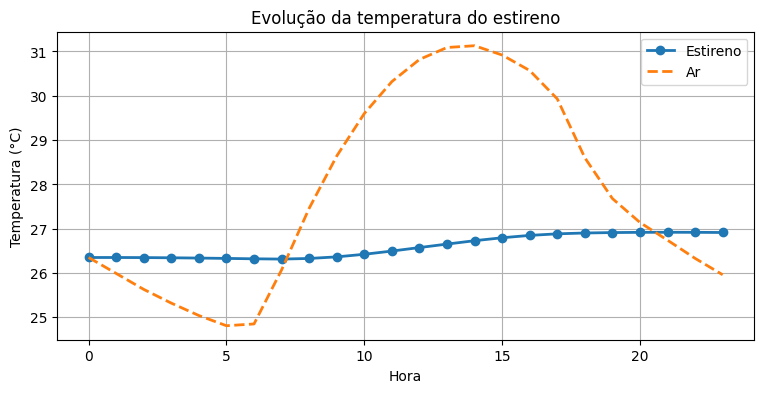

In [ ]:
# ============================================================
# 5.7 - Visualização do balnaço global
# ============================================================

# ============================================================
# Evolução da temperatura do estireno
# ============================================================

plt.figure(figsize=(9,4))

plt.plot(
    hora,
    T_est,
    '-o',
    linewidth=2,
    label="Estireno"
)

plt.plot(
    hora,
    temperatura_ar,
    '--',
    linewidth=2,
    label="Ar"
)

plt.xlabel("Hora")

plt.ylabel("Temperatura (°C)")

plt.title("Evolução da temperatura do estireno")

plt.grid(True)

plt.legend()

plt.show()

## 5.8 – Discussão dos resultados

A solução do balanço de energia mostrou que a temperatura do estireno aumentou aproximadamente **0,6 °C** ao longo do período analisado. Apesar de os fluxos de calor atingirem algumas centenas de quilowatts, a elevada massa de estireno armazenada (≈8,4×10⁶ kg) confere ao sistema grande inércia térmica, limitando a variação de temperatura a menos de **0,1 °C por hora**.

Os resultados obtidos indicam que as condições ambientais registradas no dia do acidente produziram apenas um aquecimento moderado do produto, insuficiente para provocar um aumento significativo da temperatura ou da pressão interna do tanque. Dessa forma, a simulação sugere que os efeitos da radiação solar e da convecção atmosférica, considerados isoladamente, não são suficientes para explicar o rompimento do reservatório.

Assim, nas próximas etapas do simulador serão incorporados outros fenômenos físicos, como a evolução da pressão interna, a evaporação do estireno, o vazamento e a dispersão atmosférica, permitindo uma análise mais completa dos mecanismos envolvidos no acidente.

Portanto, o rompimento deve estar associado a outro fenômeno. As hipóteses que passam a fazer sentido são:

perda de resistência mecânica da parede;

*   corrosão;
*   falha estrutural localizada;
*   sobrepressão causada por outro evento;
*   vazamento seguido de ignição;
*   falha em válvulas ou tubulações;
*   reação química (polimerização do estireno);
*   explosão externa.

# 6 – Evaporação

Na seção anterior foi determinada a evolução da temperatura do estireno por meio do balanço global de energia. Entretanto, durante o acidente ocorrido em Manaus, estimou-se que a temperatura média do líquido atingiu aproximadamente **72 °C**, valor muito superior ao previsto apenas pela ação da radiação solar e da convecção.

Surge então uma nova questão:

> **Se o estireno atingir aproximadamente 72 °C, quanta energia foi necessária para produzir esse aquecimento?**

Conhecendo essa energia, é possível responder outra pergunta importante:

> **Caso toda essa energia fosse utilizada na vaporização do estireno, qual seria a massa máxima de vapor formada?**

Embora essa hipótese represente um limite superior (situação extrema), ela estabelece uma estimativa física para a quantidade máxima de vapor que poderia ser produzida e fornece a base para a próxima etapa do simulador, dedicada à análise da pressão interna do reservatório.

EVAPORAÇÃO
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Variação de temperatura.... 45.65 °C

Energia acumulada.......... 666.98 GJ

Calor latente.............. 339.0 kJ/kg

Massa máxima evaporada..... 1967496 kg
Massa máxima evaporada..... 1967.50 t

Fração evaporada........... 23.3837 %


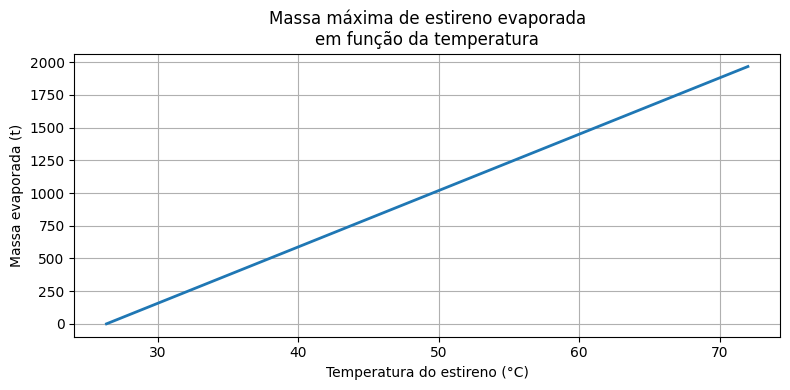

DISCUSSÃO DOS RESULTADOS
À medida que a temperatura do estireno aumenta, cresce também a quantidade de energia armazenada no sistema.

Se toda essa energia fosse utilizada exclusivamente na vaporização do estireno, seria possível evaporar a massa máxima estimada acima.

Essa condição representa um limite superior para a evaporação e será utilizada como base para estimar a quantidade de vapor disponível para o cálculo da pressão interna do reservatório.


In [ ]:
# ============================================================
# 6 - Evaporação
# ============================================================
# Cenário do acidente
#
# Temperatura observada:
# aproximadamente 72 °C
#
# Objetivo:
# Estimar a energia necessária para aquecer o estireno
# e a massa máxima que poderia ser evaporada.
# ============================================================

# ------------------------------------------------------------
# Temperatura do acidente
# ------------------------------------------------------------

T_inicial = 26.35             # resultado do balanço
T_final = 72.0                # °C

# ------------------------------------------------------------
# Calor específico
# ------------------------------------------------------------

Cp_aco = 490.0               # J/(kg.K)

massa_casco = tanque.massa_shell()

capacidade_termica = (
    massa_estireno * Cp_estireno +
    massa_casco * Cp_aco
)

# ------------------------------------------------------------
# Energia necessária para aquecer o sistema
# ------------------------------------------------------------

deltaT = T_final - T_inicial

Q_aquecimento = (
    capacidade_termica
    *
    deltaT
)

# ------------------------------------------------------------
# Calor latente do estireno
# ------------------------------------------------------------

Lv = 3.39e5      # J/kg

# ------------------------------------------------------------
# Massa máxima evaporada
# ------------------------------------------------------------

massa_evaporada = Q_aquecimento / Lv

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("EVAPORAÇÃO")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {T_final:.2f} °C")

print()

print(f"Variação de temperatura.... {deltaT:.2f} °C")

print()

print(f"Energia acumulada.......... {Q_aquecimento/1e9:.2f} GJ")

print()

print(f"Calor latente.............. {Lv/1000:.1f} kJ/kg")

print()

print(f"Massa máxima evaporada..... {massa_evaporada:.0f} kg")

print(f"Massa máxima evaporada..... {massa_evaporada/1000:.2f} t")

print()

print(
    f"Fração evaporada........... "
    f"{100*massa_evaporada/massa_estireno:.4f} %"
)

print("="*60)


temperatura = np.linspace(T_inicial,72,100)

energia = capacidade_termica * (temperatura-T_inicial)

massa = energia/Lv

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    massa/1000,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Massa evaporada (t)")

plt.title(
    "Massa máxima de estireno evaporada\n"
    "em função da temperatura"
)

plt.tight_layout()

plt.show()


print("="*60)
print("DISCUSSÃO DOS RESULTADOS")
print("="*60)

print(
    "À medida que a temperatura do estireno aumenta, cresce "
    "também a quantidade de energia armazenada no sistema."
)

print()

print(
    "Se toda essa energia fosse utilizada exclusivamente na "
    "vaporização do estireno, seria possível evaporar a massa "
    "máxima estimada acima."
)

print()

print(
    "Essa condição representa um limite superior para a "
    "evaporação e será utilizada como base para estimar a "
    "quantidade de vapor disponível para o cálculo da pressão "
    "interna do reservatório."
)

print("="*60)

# 7 – Pressão interna

Na seção anterior foi estimada a quantidade máxima de estireno que poderia ser vaporizada caso toda a energia necessária para elevar a temperatura do sistema até aproximadamente **72 °C** fosse utilizada na mudança de fase.

Surge então uma nova questão:

> **Se essa massa de vapor permanecer confinada dentro do reservatório, qual será a pressão interna desenvolvida?**

Essa pergunta é fundamental para compreender por que reservatórios aquecidos podem sofrer deformações estruturais ou até mesmo romper.

Para responder a essa questão, será adotado inicialmente um modelo simplificado baseado na **Lei dos Gases Ideais**,

\[
PV=nRT,
\]

em que:

- \(P\) é a pressão absoluta (Pa);
- \(V\) é o volume ocupado pelo vapor (m³);
- \(n\) é o número de mols de estireno evaporado;
- \(R\) é a constante universal dos gases;
- \(T\) é a temperatura absoluta (K).

Nesta etapa considera-se que:

- todo o vapor permanece confinado no espaço livre do tanque;
- o comportamento do vapor pode ser aproximado por um gás ideal;
- a temperatura do vapor é igual à temperatura média do estireno.

Embora essas hipóteses simplifiquem o fenômeno físico, elas permitem compreender como a formação de vapor influencia diretamente a pressão interna do reservatório.

Ao final desta etapa serão determinados:

1. o número de mols de estireno evaporado;
2. o volume disponível para o vapor;
3. a pressão absoluta;
4. a pressão manométrica do tanque.

Esses resultados servirão de base para a próxima seção, dedicada à análise da integridade estrutural do reservatório.

PRESSÃO INTERNA
Massa evaporada........ 1967.5 t
Volume de vapor........ 1031.9 m³
Número de mols......... 1.889e+07 mol

Temperatura............ 345.15 K

Pressão absoluta....... 52.534 MPa
Pressão manométrica.... 52.433 MPa


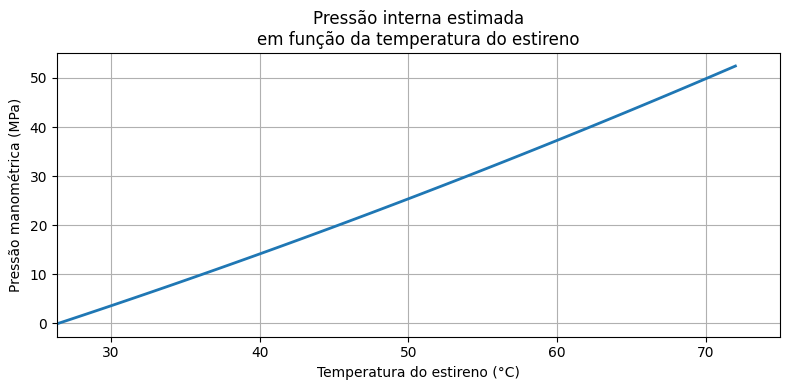

In [ ]:
# ============================================================
# 7 - Pressão interna
# ============================================================
# Modelo simplificado
#
# Lei dos Gases Ideais
#
# PV = nRT
# ============================================================

# ------------------------------------------------------------
# Dados
# ------------------------------------------------------------

R = 8.314          # J/(mol.K)

M_estireno = 104.15e-3      # kg/mol

T_vapor = 72 + 273.15       # K

# ------------------------------------------------------------
# Volume disponível ao vapor
# ------------------------------------------------------------

V_vapor = tanque.volume_vapor

# ------------------------------------------------------------
# Número de mols
# ------------------------------------------------------------

n = massa_evaporada / M_estireno

# ------------------------------------------------------------
# Pressão absoluta
# ------------------------------------------------------------

P = n * R * T_vapor / V_vapor

# ------------------------------------------------------------
# Pressão manométrica
# ------------------------------------------------------------

P_atm = 101325

P_man = P - P_atm

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("PRESSÃO INTERNA")
print("="*60)

print(f"Massa evaporada........ {massa_evaporada/1000:.1f} t")

print(f"Volume de vapor........ {V_vapor:.1f} m³")

print(f"Número de mols......... {n:.3e} mol")

print()

print(f"Temperatura............ {T_vapor:.2f} K")

print()

print(f"Pressão absoluta....... {P/1e6:.3f} MPa")

print(f"Pressão manométrica.... {P_man/1e6:.3f} MPa")

print("="*60)


# ============================================================
# Gráfico - Pressão interna em função da temperatura
# ============================================================

temperatura = np.linspace(T_inicial, 72, 100)

# ------------------------------------------------------------
# Energia acumulada
# ------------------------------------------------------------

energia = capacidade_termica * (temperatura - T_inicial)

# ------------------------------------------------------------
# Massa máxima evaporada
# ------------------------------------------------------------

massa = energia / Lv          # kg

# ------------------------------------------------------------
# Número de mols
# ------------------------------------------------------------

M_estireno = 104.15e-3        # kg/mol

n = massa / M_estireno

# ------------------------------------------------------------
# Volume de vapor
# ------------------------------------------------------------

V_vapor = tanque.volume_vapor

# ------------------------------------------------------------
# Temperatura absoluta
# ------------------------------------------------------------

T_K = temperatura + 273.15

# ------------------------------------------------------------
# Lei dos gases ideais
# ------------------------------------------------------------

R = 8.314

P = n * R * T_K / V_vapor      # Pa

# ------------------------------------------------------------
# Pressão manométrica
# ------------------------------------------------------------

P_atm = 101325

P_man = (P - P_atm) / 1e6      # MPa

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    P_man,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")
plt.ylabel("Pressão manométrica (MPa)")

plt.title(
    "Pressão interna estimada\n"
    "em função da temperatura do estireno"
)

plt.xlim(T_inicial,75)

plt.tight_layout()

plt.show()

## 6.1 – Pressão de vapor pelo modelo de Clausius-Clapeyron

Na seção anterior foi obtida uma estimativa da **pressão máxima teórica** supondo que toda a massa de estireno evaporada permanecesse confinada no espaço livre do reservatório. Embora esse resultado seja útil para estabelecer um limite superior, essa hipótese não representa o comportamento físico real do sistema.

Em um reservatório contendo simultaneamente **estireno líquido e vapor**, a pressão interna tende a ser controlada pelo **equilíbrio líquido-vapor**, sendo determinada pela pressão de vapor do estireno para cada temperatura.

Nesta etapa será utilizada a equação de **Clausius–Clapeyron**, que relaciona a pressão de vapor com a temperatura por meio do calor molar de vaporização do estireno.

Dessa forma, será possível estimar uma pressão interna mais compatível com o comportamento esperado de um tanque atmosférico aquecido, estabelecendo uma base mais realista para a análise da integridade estrutural apresentada na próxima seção.

PRESSÃO DE VAPOR - CLAUSIUS-CLAPEYRON
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Pressão de vapor a 25 °C... 0.64 kPa
Pressão de vapor a 72 °C... 4.43 kPa

Aumento da pressão......... 6.92 vezes


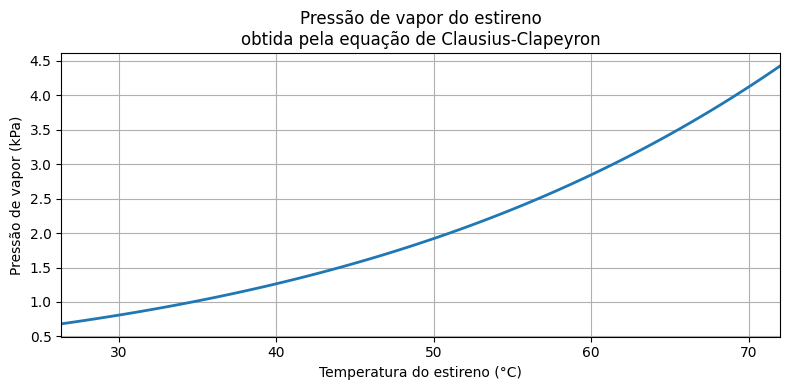

DISCUSSÃO DOS RESULTADOS

A pressão de vapor aumenta exponencialmente com a
temperatura, conforme previsto pela equação de Clausius-
Clapeyron.

Para uma temperatura de 72 °C, a pressão de vapor estimada é
de aproximadamente 4.43 kPa.

Esse valor é muito inferior à pressão estimada pelo modelo
simplificado baseado na Lei dos Gases Ideais, evidenciando
que, em equilíbrio termodinâmico, a pressão interna é
controlada pela pressão de vapor do estireno e não pela
massa máxima teoricamente evaporada.

Esse resultado demonstra a importância de utilizar modelos
físicos compatíveis com o fenômeno analisado. Embora a Lei
dos Gases Ideais forneça um limite teórico superior, a
equação de Clausius-Clapeyron representa de forma mais
realista o comportamento do estireno nas condições
estudadas.



In [ ]:
# ============================================================
# 6.1 - Pressão de vapor pelo modelo de Clausius-Clapeyron
# ============================================================

# Temperatura (°C)
temperatura = np.linspace(T_inicial, 72, 100)

# ------------------------------------------------------------
# Dados de referência
# ------------------------------------------------------------

# Pressão de vapor a 25 °C
Pv_ref = 0.64e3          # Pa

# Temperatura de referência
T_ref = 25.0 + 273.15    # K

# Calor molar de vaporização
Hvap = 35.2e3            # J/mol

# Constante universal
R = 8.314                # J/(mol.K)

# ------------------------------------------------------------
# Temperatura absoluta
# ------------------------------------------------------------

T_K = temperatura + 273.15

# ------------------------------------------------------------
# Clausius-Clapeyron
# ------------------------------------------------------------

P_vapor = Pv_ref * np.exp(
    -Hvap/R * (1/T_K - 1/T_ref)
)

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("PRESSÃO DE VAPOR - CLAUSIUS-CLAPEYRON")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {temperatura[-1]:.2f} °C")

print()

print(f"Pressão de vapor a 25 °C... {Pv_ref/1000:.2f} kPa")
print(f"Pressão de vapor a 72 °C... {P_vapor[-1]/1000:.2f} kPa")

print()

print(f"Aumento da pressão......... {P_vapor[-1]/Pv_ref:.2f} vezes")

print("="*60)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    P_vapor/1000,
    linewidth=2
)

plt.grid(True)

plt.xlim(T_inicial,72)

plt.xlabel("Temperatura do estireno (°C)")
plt.ylabel("Pressão de vapor (kPa)")

plt.title(
    "Pressão de vapor do estireno\n"
    "obtida pela equação de Clausius-Clapeyron"
)

plt.tight_layout()

plt.show()

# ============================================================
# Discussão
# ============================================================

def imprimir(texto):
    print(textwrap.fill(texto, width=60))
    print()

print("="*60)
print("DISCUSSÃO DOS RESULTADOS")
print("="*60)
print()

imprimir(
    "A pressão de vapor aumenta exponencialmente com a "
    "temperatura, conforme previsto pela equação de "
    "Clausius-Clapeyron."
)

imprimir(
    f"Para uma temperatura de 72 °C, a pressão de vapor "
    f"estimada é de aproximadamente "
    f"{P_vapor[-1]/1000:.2f} kPa."
)

imprimir(
    "Esse valor é muito inferior à pressão estimada pelo "
    "modelo simplificado baseado na Lei dos Gases Ideais, "
    "evidenciando que, em equilíbrio termodinâmico, a "
    "pressão interna é controlada pela pressão de vapor do "
    "estireno e não pela massa máxima teoricamente "
    "evaporada."
)

imprimir(
    "Esse resultado demonstra a importância de utilizar "
    "modelos físicos compatíveis com o fenômeno analisado. "
    "Embora a Lei dos Gases Ideais forneça um limite teórico "
    "superior, a equação de Clausius-Clapeyron representa de "
    "forma mais realista o comportamento do estireno nas "
    "condições estudadas."
)

print("="*60)

# 7 – Energia liberada pela polimerização

Nas seções anteriores foi demonstrado que a radiação solar e a convecção atmosférica produzem apenas um pequeno aumento na temperatura do estireno armazenado no reservatório. Entretanto, as análises térmicas do acidente indicaram que a temperatura média do líquido atingiu aproximadamente **72 °C**, valor muito superior ao previsto apenas pelos mecanismos de transferência de calor considerados.

Surge então uma nova questão:

> **Quanto estireno precisou sofrer polimerização para fornecer a energia necessária para elevar a temperatura do sistema até aproximadamente 72 °C?**

A polimerização do estireno é uma reação química exotérmica, ou seja, libera energia na forma de calor. Admitindo que esse calor permaneça armazenado no sistema, a energia liberada pela reação pode ser estimada por

$$
Q_{pol}=m_{pol}\Delta H_{pol}
$$

em que:

- $Q_{pol}$ é a energia liberada pela reação (J);
- $m_{pol}$ é a massa de estireno que sofreu polimerização (kg);
- $\Delta H_{pol}$ é o calor específico de polimerização (J/kg).

Como a energia necessária para elevar a temperatura do sistema de aproximadamente **26,35 °C** para **72 °C** já foi determinada na Seção 6, pode-se inverter essa equação para estimar diretamente a massa que precisou reagir,

$$
m_{pol}=\frac{Q_{pol}}{\Delta H_{pol}}
$$

Ao final desta seção serão determinados:

1. a energia necessária para explicar o aquecimento observado;
2. a massa de estireno polimerizada;
3. a fração da massa total que reagiu.

Esses resultados serão utilizados posteriormente para discutir como a polimerização pode intensificar a evaporação e contribuir para o aumento da pressão interna do reservatório.

POLIMERIZAÇÃO
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Variação de temperatura.... 45.65 °C

Energia necessária......... 666.98 GJ

Calor de polimerização..... 670 kJ/kg

Massa polimerizada......... 995.49 t

Fração polimerizada........ 11.83 %


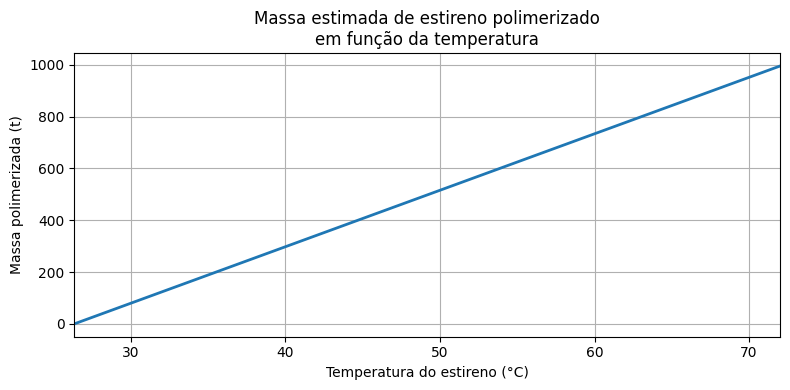

DISCUSSÃO DOS RESULTADOS

Os resultados mostram que a energia necessária para elevar a
temperatura do sistema até aproximadamente 72 °C pode ser
fornecida pela polimerização de apenas uma fração da massa
total de estireno armazenada no reservatório.

Embora essa fração seja relativamente pequena quando
comparada à massa total armazenada, a energia liberada pela
reação é suficiente para explicar o aquecimento
significativo observado durante o acidente.

O aumento da temperatura intensifica a evaporação do
estireno e favorece o crescimento da pressão de vapor no
interior do reservatório, evidenciando a forte interação
entre os fenômenos químicos e térmicos.

Nesta análise, a polimerização foi considerada como a
principal fonte de energia responsável pelo aquecimento do
sistema, estabelecendo uma ligação direta entre a reação
química e os modelos de evaporação e pressão desenvolvidos
nas seções anteriores.

Na próxima etapa, a condição térmica obtida será utilizada
para analisar a dispers

In [ ]:
# ============================================================
# 7 - Energia liberada pela polimerização
# ============================================================
#
# Objetivo:
#
# Estimar qual massa de estireno precisou sofrer
# polimerização para elevar a temperatura do sistema
# até aproximadamente 72 °C.
#
# ============================================================

# ------------------------------------------------------------
# Temperaturas
# ------------------------------------------------------------

T_inicial = T_est[0]

T_final = 72.0

deltaT = T_final - T_inicial

# ------------------------------------------------------------
# Energia necessária
# ------------------------------------------------------------

Q_pol = capacidade_termica * deltaT

# ------------------------------------------------------------
# Calor de polimerização
# ------------------------------------------------------------

# Entalpia específica de polimerização do estireno
# Chen, Duh e Shu (2009)

DeltaH_pol = 670e3      # J/kg

# ------------------------------------------------------------
# Massa polimerizada
# ------------------------------------------------------------

massa_pol = Q_pol / DeltaH_pol

# ------------------------------------------------------------
# Fração polimerizada
# ------------------------------------------------------------

fracao_pol = massa_pol / massa_estireno



# ============================================================
# Resultados
# ============================================================

print("="*60)
print("POLIMERIZAÇÃO")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {T_final:.2f} °C")

print()

print(f"Variação de temperatura.... {deltaT:.2f} °C")

print()

print(f"Energia necessária......... {Q_pol/1e9:.2f} GJ")

print()

print(f"Calor de polimerização..... {DeltaH_pol/1000:.0f} kJ/kg")

print()

print(f"Massa polimerizada......... {massa_pol/1000:.2f} t")

print()

print(f"Fração polimerizada........ {100*fracao_pol:.2f} %")

print("="*60)



# ============================================================
# Influência da temperatura na massa polimerizada
# ============================================================

temperatura = np.linspace(T_inicial,72,100)

energia = capacidade_termica * (
    temperatura - T_inicial
)

massa_pol = energia / DeltaH_pol

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    massa_pol/1000,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Massa polimerizada (t)")

plt.title(
    "Massa estimada de estireno polimerizado\n"
    "em função da temperatura"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()


# ============================================================
# Discussão
# ============================================================

def imprimir(texto):
    print(textwrap.fill(texto, width=60))
    print()

print("="*60)
print("DISCUSSÃO DOS RESULTADOS")
print("="*60)
print()

imprimir(
    "Os resultados mostram que a energia necessária para "
    "elevar a temperatura do sistema até aproximadamente "
    "72 °C pode ser fornecida pela polimerização de apenas "
    "uma fração da massa total de estireno armazenada no "
    "reservatório."
)

imprimir(
    "Embora essa fração seja relativamente pequena quando "
    "comparada à massa total armazenada, a energia liberada "
    "pela reação é suficiente para explicar o aquecimento "
    "significativo observado durante o acidente."
)

imprimir(
    "O aumento da temperatura intensifica a evaporação do "
    "estireno e favorece o crescimento da pressão de vapor "
    "no interior do reservatório, evidenciando a forte "
    "interação entre os fenômenos químicos e térmicos."
)

imprimir(
    "Nesta análise, a polimerização foi considerada como a "
    "principal fonte de energia responsável pelo aquecimento "
    "do sistema, estabelecendo uma ligação direta entre a "
    "reação química e os modelos de evaporação e pressão "
    "desenvolvidos nas seções anteriores."
)

imprimir(
    "Na próxima etapa, a condição térmica obtida será "
    "utilizada para analisar a dispersão atmosférica do "
    "estireno após sua liberação para o ambiente."
)

print("="*60)

# 8 – Integridade estrutural

Na seção anterior foi estimada a pressão interna desenvolvida no reservatório a partir de dois modelos distintos.

O modelo baseado na Lei dos Gases Ideais forneceu uma condição limite, enquanto a equação de Clausius–Clapeyron produziu valores compatíveis com o equilíbrio líquido-vapor do estireno.

Surge então uma nova questão:

> **A pressão interna estimada é suficiente para comprometer a integridade estrutural do tanque?**

Para responder essa pergunta será utilizado um modelo simplificado baseado na teoria de cascas cilíndricas de parede fina.

Embora reservatórios atmosféricos sejam projetados conforme a norma API 650, as equações clássicas para vasos de pressão permitem estimar a ordem de grandeza das tensões desenvolvidas na parede do tanque e comparar esses valores com o limite de escoamento do aço ASTM A36.

A tensão circunferencial (ou tensão de aro) é dada por

$$
\sigma_\theta
=
\frac{Pr}{t},
$$

em que

- $P$ é a pressão interna (Pa);
- $r$ é o raio interno do tanque (m);
- $t$ é a espessura da parede (m).

A tensão longitudinal pode ser estimada por

$$
\sigma_L
=
\frac{Pr}{2t}.
$$

Finalmente, o fator de segurança é calculado por

$$
FS
=
\frac{\sigma_y}
{\sigma_\theta},
$$

em que $\sigma_y$ representa o limite de escoamento do aço ASTM A36.

Ao final desta seção serão determinados:

1. tensão circunferencial;
2. tensão longitudinal;
3. fator de segurança do reservatório.

Esses resultados permitirão avaliar se a pressão interna calculada nas seções anteriores seria capaz de produzir plastificação da parede do tanque.

INTEGRIDADE ESTRUTURAL
Pressão interna............. 4.43 kPa

Raio do tanque.............. 13.70 m
Espessura mínima........... 6.0 mm

Tensão circunferencial...... 10.105 MPa
Tensão longitudinal......... 5.053 MPa

Limite de escoamento........ 250 MPa
Fator de segurança.......... 24.7


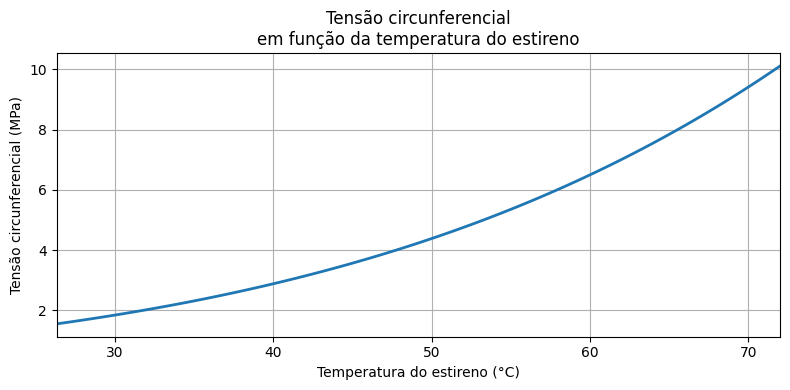

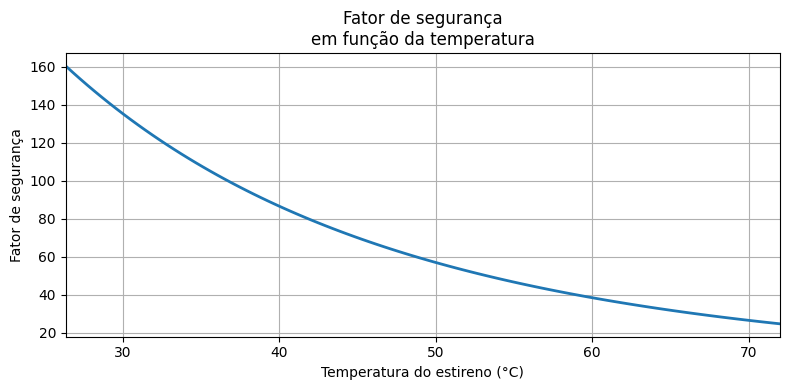

CONCLUSÃO

Nesta seção foi aplicado um modelo simplificado de
Resistência dos Materiais para estimar as tensões
desenvolvidas na parede de um reservatório cilíndrico
submetido à pressão interna.

Os resultados mostram que a pressão de vapor do estireno
pode ser convertida diretamente em tensões circunferenciais
e longitudinais por meio das equações clássicas para vasos
de pressão de parede fina.

Mesmo considerando a espessura mínima do casco, que
representa a condição estrutural mais crítica para uma
pressurização uniforme, as tensões permanecem muito
inferiores ao limite de escoamento do aço ASTM A36.

Consequentemente, nas hipóteses adotadas neste modelo, a
pressão de vapor do estireno não é suficiente para provocar
plastificação ou ruptura da parede do reservatório.

Esse resultado mostra que a integridade estrutural do tanque
não depende exclusivamente da pressão interna. Fenômenos
como a polimerização exotérmica, aquecimentos localizados,
degradação das propriedades mecânicas do 

In [ ]:
# ============================================================
# 8 - Integridade estrutural
# ============================================================
#
# Modelo:
#
# Casca cilíndrica de parede fina
#
# ============================================================

# ------------------------------------------------------------
# Propriedades do material
# ------------------------------------------------------------

sigma_escoamento = 250e6      # Pa (ASTM A36)

# ------------------------------------------------------------
# Geometria
# ------------------------------------------------------------

r = tanque.raio

# Espessura mínima do casco
# (condição mais crítica)

t = np.min(tanque.espessuras)

# ------------------------------------------------------------
# Pressão interna
# ------------------------------------------------------------

# Utiliza o modelo físico mais realista

P = P_vapor[-1]

# ------------------------------------------------------------
# Tensões
# ------------------------------------------------------------

sigma_theta = P * r / t

sigma_long = P * r / (2*t)

# ------------------------------------------------------------
# Fator de segurança
# ------------------------------------------------------------

FS = sigma_escoamento / sigma_theta

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("INTEGRIDADE ESTRUTURAL")
print("="*60)

print(f"Pressão interna............. {P/1000:.2f} kPa")

print()

print(f"Raio do tanque.............. {r:.2f} m")
print(f"Espessura mínima........... {1000*t:.1f} mm")

print()

print(f"Tensão circunferencial...... {sigma_theta/1e6:.3f} MPa")
print(f"Tensão longitudinal......... {sigma_long/1e6:.3f} MPa")

print()

print(f"Limite de escoamento........ {sigma_escoamento/1e6:.0f} MPa")

print(f"Fator de segurança.......... {FS:.1f}")

print("="*60)




temperatura = np.linspace(T_inicial,72,100)

T_K = temperatura + 273.15

P = Pv_ref*np.exp(
    -Hvap/R*(1/T_K-1/T_ref)
)

sigma = P*r/t

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    sigma/1e6,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Tensão circunferencial (MPa)")

plt.title(
    "Tensão circunferencial\n"
    "em função da temperatura do estireno"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()



FS = sigma_escoamento/sigma

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    FS,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Fator de segurança")

plt.title(
    "Fator de segurança\n"
    "em função da temperatura"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()


# ============================================================
# Conclusão
# ============================================================

import textwrap

def imprimir(texto):
    print(textwrap.fill(texto, width=60))
    print()

print("="*60)
print("CONCLUSÃO")
print("="*60)
print()

imprimir(
    "Nesta seção foi aplicado um modelo simplificado de "
    "Resistência dos Materiais para estimar as tensões "
    "desenvolvidas na parede de um reservatório cilíndrico "
    "submetido à pressão interna."
)

imprimir(
    "Os resultados mostram que a pressão de vapor do "
    "estireno pode ser convertida diretamente em tensões "
    "circunferenciais e longitudinais por meio das "
    "equações clássicas para vasos de pressão de parede "
    "fina."
)

imprimir(
    "Mesmo considerando a espessura mínima do casco, que "
    "representa a condição estrutural mais crítica para "
    "uma pressurização uniforme, as tensões permanecem "
    "muito inferiores ao limite de escoamento do aço "
    "ASTM A36."
)

imprimir(
    "Consequentemente, nas hipóteses adotadas neste "
    "modelo, a pressão de vapor do estireno não é "
    "suficiente para provocar plastificação ou ruptura "
    "da parede do reservatório."
)

imprimir(
    "Esse resultado mostra que a integridade estrutural "
    "do tanque não depende exclusivamente da pressão "
    "interna. Fenômenos como a polimerização "
    "exotérmica, aquecimentos localizados, degradação "
    "das propriedades mecânicas do material, falhas "
    "dos dispositivos de alívio e outras condições "
    "operacionais podem contribuir para o "
    "desenvolvimento de sobrepressões e danos "
    "estruturais."
)

imprimir(
    "Assim, este modelo constitui uma ferramenta "
    "didática para integrar conceitos de "
    "Termodinâmica, Transferência de Calor e "
    "Resistência dos Materiais, mostrando como a "
    "pressão interna pode ser utilizada para avaliar "
    "a integridade estrutural de reservatórios "
    "cilíndricos."
)

print("="*60)

# 9 – Dispersão atmosférica

Nas seções anteriores foram estudados os fenômenos que ocorrem no interior do reservatório: transferência de calor, evaporação, pressão interna, polimerização e integridade estrutural.

Surge então uma nova pergunta:

> **Depois que o estireno é liberado para a atmosfera, como ele se espalha pelo ambiente?**

Essa questão é extremamente importante em acidentes industriais, pois a concentração do contaminante no ar determina os riscos à saúde da população e aos trabalhadores próximos ao local.

Nesta seção será utilizado um modelo simplificado para representar a dispersão atmosférica do estireno após um vazamento.

Antes de realizar qualquer cálculo, é importante observar que a nuvem de contaminante sofre a ação de dois processos físicos principais:

- **advecção**, causada pelo vento, que transporta a nuvem na direção do escoamento atmosférico;
- **difusão turbulenta**, responsável pelo espalhamento lateral e vertical da pluma.

Esses dois mecanismos explicam por que um vazamento inicialmente concentrado tende a ocupar uma região cada vez maior à medida que se afasta da fonte emissora.

O modelo mais utilizado para representar esse processo é o **modelo da pluma gaussiana**, cuja concentração é dada por

$$
C(x,y,z)=
\frac{Q}
{2\pi u\sigma_y\sigma_z}
\exp\left(
-\frac{y^2}{2\sigma_y^2}
\right)
\left[
\exp\left(
-\frac{(z-H)^2}{2\sigma_z^2}
\right)
+
\exp\left(
-\frac{(z+H)^2}{2\sigma_z^2}
\right)
\right],
$$

em que:

- $C$ é a concentração do contaminante (g/m³);
- $Q$ é a taxa de emissão da fonte (g/s);
- $u$ é a velocidade média do vento (m/s);
- $\sigma_y$ é o coeficiente de dispersão lateral (m);
- $\sigma_z$ é o coeficiente de dispersão vertical (m);
- $H$ é a altura da fonte emissora (m).

Nesta primeira aplicação será analisada apenas a **linha central da pluma**, isto é,

$$
y=0
\qquad\text{e}\qquad
z=0.
$$

Nessas condições, a equação anterior simplifica-se para

$$
C(x)=
\frac{Q}
{2\pi u\sigma_y\sigma_z}
\exp\left(
-\frac{H^2}
{2\sigma_z^2}
\right),
$$

permitindo estudar como a concentração varia apenas com a distância da fonte.

Ao final desta seção serão determinados:

1. a concentração de estireno ao longo da direção do vento;
2. a influência da velocidade do vento na dispersão da pluma;
3. a redução da concentração com o aumento da distância da fonte.

Embora simplificado, esse modelo é amplamente utilizado em estudos ambientais, segurança de processos e análises preliminares de acidentes industriais, constituindo uma importante ferramenta para compreender os mecanismos básicos de dispersão atmosférica.

*Reflexão*

Antes de apresentar o modelo matemático, vale refletir sobre a seguinte questão:

> **Antes de analisar a equação, tente prever qualitativamente como cada parâmetro influencia a concentração do contaminante.**

Intuitivamente, espera-se que:

- uma **maior taxa de emissão ($Q$)** aumente a concentração do contaminante;
- uma **maior velocidade do vento ($u$)** favoreça a diluição da pluma, reduzindo sua concentração;
- um **maior espalhamento lateral ($\sigma_y$) e vertical ($\sigma_z$)** distribua o contaminante em um volume maior de ar, diminuindo a concentração na região central da pluma.

### Dados de entrada:

Para tornar esta atividade integrada às seções anteriores, alguns parâmetros do modelo serão obtidos a partir dos resultados já calculados ao longo do notebook.

**Taxa de emissão ($Q$):** será estimada admitindo-se, para fins didáticos, que a massa máxima evaporada obtida na Seção 6 seja liberada uniformemente durante um intervalo de tempo $\Delta t$. Assim,

$$
Q=\frac{m_{ev}}{\Delta t},
$$

em que $m_{ev}$ é a massa evaporada e $\Delta t$ representa a duração do vazamento.

**Velocidade do vento ($u$):** será adotada a velocidade média obtida a partir dos dados meteorológicos da plataforma **NASA POWER**, utilizada nas seções anteriores.

**Altura da fonte ($H$):** será considerada a altura do reservatório estimada por meio de imagens do Google Earth/Google Maps.

Obs: A massa evaporada utilizada na pluma gaussiana é um limite teórico energético, não uma estimativa da massa efetivamente liberada durante o acidente.

In [ ]:
# ============================================================
# 8 - Dispersão Atmosférica
# ============================================================
#
# Modelo simplificado
#
# Pluma Gaussiana
#
# Objetivo:
#
# Estimar a concentração de estireno ao longo da direção
# do vento após um vazamento.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Taxa de emissão
# ------------------------------------------------------------
# A taxa média de emissão é calculada utilizando a massa
# evaporada estimada na Seção 6.
#
# Hipótese didática:
# toda a massa evaporada é liberada uniformemente durante
# um intervalo de tempo Δt.
# ------------------------------------------------------------

tempo_vazamento = 24      # h

tempo_seg = tempo_vazamento * 3600

Q = massa_evaporada / tempo_seg      # kg/s

# ------------------------------------------------------------
# Velocidade média do vento
# ------------------------------------------------------------
# Média obtida a partir dos dados meteorológicos da
# plataforma NASA POWER.
#
# Caso a variável já tenha sido criada anteriormente,
# basta utilizá-la diretamente.
# ------------------------------------------------------------

# Velocidade média do vento obtida da plataforma NASA POWER

u = np.mean(vento)     # m/s

# ------------------------------------------------------------
# Altura da fonte
# ------------------------------------------------------------
# Utiliza a altura do reservatório definida na seção de
# geometria do tanque.
# ------------------------------------------------------------

H = tanque.altura      # m

# ------------------------------------------------------------
# Distância da fonte
# ------------------------------------------------------------

x = np.linspace(1,1000,400)

# ------------------------------------------------------------
# Classe de estabilidade atmosférica
# ------------------------------------------------------------
# Classe D de Pasquill-Gifford
# (condição atmosférica neutra)
# ------------------------------------------------------------

sigma_y = (
    0.08*x*
    (1+0.0001*x)**(-0.5)
)

sigma_z = (
    0.06*x*
    (1+0.0015*x)**(-0.5)
)

# ------------------------------------------------------------
# Concentração na linha central da pluma
# ------------------------------------------------------------

C = (
    Q /
    (
        2*np.pi*u*sigma_y*sigma_z
    )
) * np.exp(
    -(H**2)/(2*sigma_z**2)
)

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("DISPERSÃO ATMOSFÉRICA")
print("="*60)

print(f"Massa evaporada............. {massa_evaporada/1000:.1f} t")

print(f"Tempo do vazamento.......... {tempo_vazamento:.1f} h")

print()

print(f"Taxa média de emissão....... {Q:.2f} kg/s")

print()

print(f"Velocidade média do vento... {u:.2f} m/s")

print(f"Altura da fonte............. {H:.1f} m")

print("Classe atmosférica.......... D")

print()

print(f"Concentração máxima......... {1e6*C.max():.1f} mg/m³")

indice500 = np.argmin(np.abs(x-500))

print(f"Concentração a 500 m........ {1e6*C[indice500]:.1f} mg/m³")

print(f"Concentração a 1000 m....... {1e6*C[-1]:.1f} mg/m³")

print("="*60)

DISPERSÃO ATMOSFÉRICA
Massa evaporada............. 1967.5 t
Tempo do vazamento.......... 24.0 h

Taxa média de emissão....... 22.77 kg/s

Velocidade média do vento... 1.42 m/s
Altura da fonte............. 17.5 m
Classe atmosférica.......... D

Concentração máxima......... 3991.5 mg/m³
Concentração a 500 m........ 2141.1 mg/m³
Concentração a 1000 m....... 791.4 mg/m³


## 9.1 – Visualização da concentração ao longo da direção do vento

Após definir os parâmetros da fonte emissora e das condições meteorológicas, pode-se calcular como a concentração de estireno varia ao longo da direção do vento utilizando o modelo da pluma gaussiana.

Nesta análise é considerada a **linha central da pluma** (\(y=0\) e \(z=0\)), região onde são previstas as maiores concentrações do contaminante. À medida que a distância da fonte aumenta, a ação do vento e da difusão turbulenta promove o espalhamento da pluma, reduzindo progressivamente a concentração de estireno na atmosfera.

O gráfico a seguir apresenta a concentração de estireno, expressa em **mg/m³**, em função da distância da fonte emissora. A partir dessa análise, é possível identificar as regiões mais afetadas pelo vazamento e compreender a influência da dispersão atmosférica na redução da concentração do contaminante.

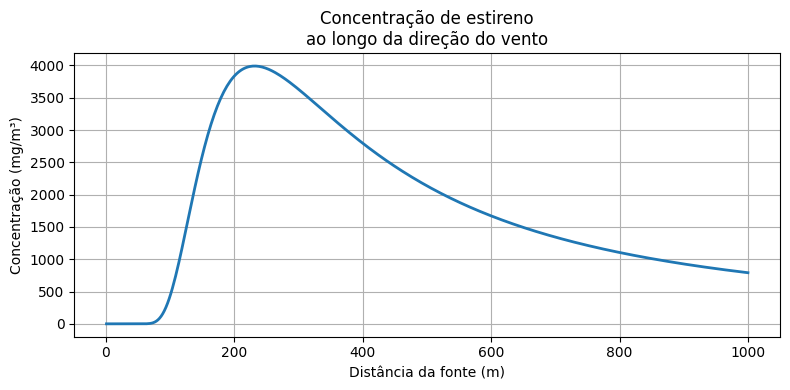

In [ ]:
# ===============================================================
# 9.1 - Visualização da concentração ao longo da direção do vento
# ===============================================================

plt.figure(figsize=(8,4))

plt.plot(
    x,
    C*1e6,          # kg/m³ -> mg/m³
    linewidth=2
)

plt.grid(True)

plt.xlabel("Distância da fonte (m)")

plt.ylabel("Concentração (mg/m³)")

plt.title(
    "Concentração de estireno\n"
    "ao longo da direção do vento"
)

plt.tight_layout()

plt.show()

## 9.2 – Influência da velocidade do vento

A velocidade do vento é um dos principais fatores que controlam a dispersão de contaminantes na atmosfera. Em geral, ventos mais intensos transportam a pluma com maior rapidez e promovem uma diluição mais eficiente do poluente, reduzindo sua concentração ao longo da direção do escoamento.

Para investigar esse efeito, serão simulados diferentes valores de velocidade do vento, mantendo constantes os demais parâmetros do modelo. Dessa forma, é possível avaliar como as condições meteorológicas influenciam a concentração de estireno prevista pelo modelo da pluma gaussiana.

O gráfico a seguir apresenta a variação da concentração de estireno, expressa em **mg/m³**, em função da distância da fonte emissora para diferentes velocidades médias do vento.

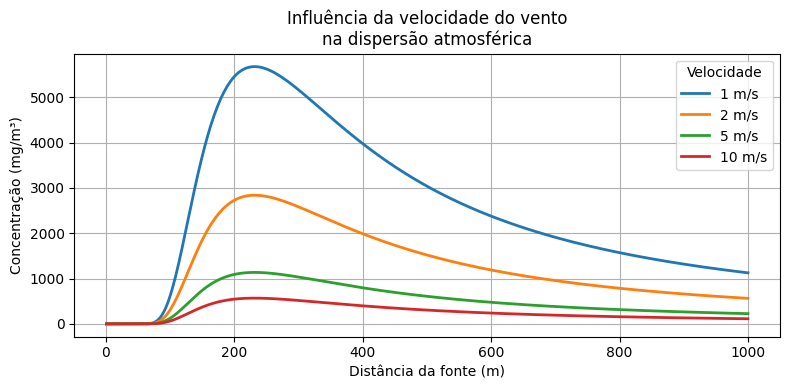

In [ ]:
# ============================================================
# 9.2 - Influência da velocidade do vento
# ============================================================

plt.figure(figsize=(8,4))

for u in [1, 2, 5, 10]:

    C = (
        Q
        /
        (
            2*np.pi*u*sigma_y*sigma_z
        )
        *
        np.exp(
            -(H**2)/(2*sigma_z**2)
        )
    )

    plt.plot(
        x,
        C*1e6,              # kg/m³ → mg/m³
        linewidth=2,
        label=f"{u} m/s"
    )

plt.grid(True)

plt.xlabel("Distância da fonte (m)")

plt.ylabel("Concentração (mg/m³)")

plt.title(
    "Influência da velocidade do vento\n"
    "na dispersão atmosférica"
)

plt.legend(title="Velocidade")

plt.tight_layout()

plt.show()

### 9.3 - Conclusão

In [ ]:
# ============================================================
# 9.3 - Conclusão
# ============================================================

def imprimir(texto):
    print(textwrap.fill(texto, width=60))
    print()

print("="*60)
print("CONCLUSÃO")
print("="*60)
print()

imprimir(
    "Os resultados mostram que a concentração de estireno "
    "diminui progressivamente à medida que a pluma se afasta "
    "da fonte emissora, evidenciando o efeito da diluição "
    "atmosférica."
)

imprimir(
    "Observa-se também que velocidades de vento mais elevadas "
    "favorecem o transporte e o espalhamento do contaminante, "
    "reduzindo sua concentração na região central da pluma."
)

imprimir(
    "Neste notebook, a taxa de emissão foi estimada a partir "
    "da massa evaporada calculada anteriormente, mostrando "
    "como os resultados das etapas de evaporação podem ser "
    "utilizados como dados de entrada para a análise da "
    "dispersão atmosférica."
)

imprimir(
    "Embora o modelo da pluma gaussiana represente uma "
    "aproximação simplificada, ele constitui uma ferramenta "
    "amplamente empregada em estudos preliminares de segurança "
    "de processos, avaliação de riscos e engenharia ambiental, "
    "permitindo compreender como as condições meteorológicas "
    "influenciam a propagação de contaminantes na atmosfera."
)

imprimir(
    "Com esta etapa, conclui-se a sequência de modelos "
    "desenvolvida neste notebook, relacionando o aquecimento "
    "do reservatório, a evaporação do estireno, a pressão "
    "interna, a integridade estrutural e, por fim, a "
    "dispersão atmosférica do contaminante após sua liberação."
)

print("="*60)

CONCLUSÃO

Os resultados mostram que a concentração de estireno diminui
progressivamente à medida que a pluma se afasta da fonte
emissora, evidenciando o efeito da diluição atmosférica.

Observa-se também que velocidades de vento mais elevadas
favorecem o transporte e o espalhamento do contaminante,
reduzindo sua concentração na região central da pluma.

Neste notebook, a taxa de emissão foi estimada a partir da
massa evaporada calculada anteriormente, mostrando como os
resultados das etapas de evaporação podem ser utilizados
como dados de entrada para a análise da dispersão
atmosférica.

Embora o modelo da pluma gaussiana represente uma
aproximação simplificada, ele constitui uma ferramenta
amplamente empregada em estudos preliminares de segurança de
processos, avaliação de riscos e engenharia ambiental,
permitindo compreender como as condições meteorológicas
influenciam a propagação de contaminantes na atmosfera.

Com esta etapa, conclui-se a sequência de modelos
desenvolvida neste n

#    Fluxo metodológico da sequência didática proposta.
1.   ACIDENTE
2.   Coleta e organização dos dados
3.   Construção progressiva dos modelos
 *   Geometria                                 
 *   Condições ambientais                      
 *   Transferência de calor                    
 *   Balanço de energia                        
 *   Evaporação                                
 *   Pressão interna                           
 *   Polimerização                             
 *   Integridade estrutural                    
 *   Dispersão atmosférica
4.   Implementação em Python/Colab
5.   Simulação • Investigação • Discussão
6.   Integração dos conteúdos de Física